<a href="https://colab.research.google.com/github/manuelcebrianramos/open-llm-multimodality-dynamics/blob/main/VLM_Ecosystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0) Colab `setup`

In [ ]:
!pip -q install datasets pandas pyarrow tqdm



In [ ]:
import re
from collections import Counter, defaultdict
from datetime import datetime
import pandas as pd
from tqdm.auto import tqdm
from datasets import load_dataset


# 1) Load the dataset (streaming) + inspect one row

This dataset includes fields like model_id, tags, pipeline_tag, library_name, createdAt, etc.

In [ ]:
from datasets import load_dataset

DATASET = "modelbiome/ai_ecosystem_withmodelcards"

# get one row to see schema
ds0 = load_dataset(DATASET, split="train", streaming=True)
row0 = next(iter(ds0))

KEEP = ["model_id", "pipeline_tag", "tags", "library_name", "createdAt", "modelCard",
        "finetune_parent", "quantized_parent", "adapter_parent", "merge_parent"]

USECOLS = [c for c in KEEP if c in row0.keys()]
ds = load_dataset(DATASET, split="train", streaming=True, usecols=USECOLS)

next(iter(ds))


{'model_id': 'moonshotai/Kimi-K2-Instruct',
 'tags': "['transformers', 'safetensors', 'kimi_k2', 'text-generation', 'conversational', 'custom_code', 'doi:10.57967/hf/5976', 'license:other', 'autotrain_compatible', 'endpoints_compatible', 'fp8', 'region:us']",
 'pipeline_tag': 'text-generation',
 'library_name': 'transformers',
 'createdAt': '2025-07-11T00:55:12.000Z',
 'finetune_parent': '[]',
 'quantized_parent': '[]',
 'adapter_parent': '[]',
 'merge_parent': '[]',
 'modelCard': '---\nlicense: other\nlicense_name: modified-mit\nlibrary_name: transformers\n---\n<div align="center">\n  <picture>\n      <img src="figures/kimi-logo.png" width="30%" alt="Kimi K2: Open Agentic Intellignece">\n  </picture>\n</div>\n\n<hr>\n\n<div align="center" style="line-height:1">\n  <a href="https://www.kimi.com" target="_blank"><img alt="Chat" src="https://img.shields.io/badge/🤖%20Chat-Kimi%20K2-ff6b6b?color=1783ff&logoColor=white"/></a>\n  <a href="https://github.com/moonshotai/Kimi-K2"><img alt="gith

Nice — that output means usecols= worked and you’re streaming only the columns you want. Also confirms the key quirks:

tags is a stringified Python list (e.g., "['transformers', ...]")

the parent fields are stringified lists too (here they’re '[]')

model card text is in modelCard (capital C)

(all visible in your sample row)

Below are the next Colab cells to keep going.

# Cell A — helpers: parse list-ish strings + month bucketing

In [ ]:
import ast
from datetime import datetime

def parse_listish(x):
    """Turn "['a','b']" or "[]" into a Python list."""
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s == "[]":
            return []
        try:
            v = ast.literal_eval(s)
            return v if isinstance(v, list) else [v]
        except Exception:
            return []
    return []

def parse_month(createdAt):
    """Return YYYY-MM from HF createdAt like 2025-07-11T00:55:12.000Z."""
    if not createdAt:
        return None
    try:
        dt = datetime.fromisoformat(createdAt.replace("Z", "+00:00"))
        return f"{dt.year:04d}-{dt.month:02d}"
    except Exception:
        return None


# Cell B — define multimodal + LLM-ish filters (simple version)

You can refine later (e.g., allow text-generation-inference, etc.). Your sample row is exactly the kind of thing this will classify as LLM-ish.

In [ ]:
import re

MULTIMODAL_PIPELINE_TAGS = {
    "text-to-image",
    "image-to-text",
    "image-text-to-text",
    "audio-to-audio",
    "any-to-any",
}

def is_multimodal(pipeline_tag):
    return (pipeline_tag or "") in MULTIMODAL_PIPELINE_TAGS

def is_llmish(row):
    # Conservative proxy: transformers + tagged as text-generation somewhere
    lib = (row.get("library_name") or "").lower()
    pt = (row.get("pipeline_tag") or "").lower()
    tags = [t.lower() for t in parse_listish(row.get("tags"))]

    return (lib == "transformers") and (pt == "text-generation" or "text-generation" in tags)



# Cell C — stream and aggregate (start with a small cap)
This avoids waiting forever on 1.86M rows while you debug.

In [ ]:
from collections import Counter
from tqdm.auto import tqdm

counts_all = Counter()
mm_all = Counter()

counts_llm = Counter()
mm_llm = Counter()

pipeline_counts = Counter()

MAX_ROWS = 200_000  # debug first; later set to None for full pass

for i, row in enumerate(tqdm(ds, total=MAX_ROWS)):
    if MAX_ROWS is not None and i >= MAX_ROWS:
        break

    month = parse_month(row.get("createdAt"))
    if not month:
        continue

    pt = row.get("pipeline_tag")
    pipeline_counts[pt] += 1

    counts_all[month] += 1
    if is_multimodal(pt):
        mm_all[month] += 1

    if is_llmish(row):
        counts_llm[month] += 1
        if is_multimodal(pt):
            mm_llm[month] += 1


  0%|          | 0/200000 [00:00<?, ?it/s]

# Cell D — build a dataframe + quick plot

In [ ]:
import pandas as pd

months = sorted(counts_all.keys())

df = pd.DataFrame({
    "month": months,
    "n_all": [counts_all[m] for m in months],
    "mm_all": [mm_all[m] for m in months],
    "share_mm_all": [mm_all[m] / counts_all[m] if counts_all[m] else 0 for m in months],
    "n_llm": [counts_llm[m] for m in months],
    "mm_llm": [mm_llm[m] for m in months],
    "share_mm_llm": [mm_llm[m] / counts_llm[m] if counts_llm[m] else 0 for m in months],
})

df.tail(12)


,month,n_all,mm_all,share_mm_all,n_llm,mm_llm,share_mm_llm
29,2024-08,123,35,0.284553,22,1,0.045455
30,2024-09,169,22,0.130178,57,2,0.035088
31,2024-10,144,23,0.159722,29,1,0.034483
32,2024-11,148,29,0.195946,36,2,0.055556
33,2024-12,174,18,0.103448,33,0,0.000000
34,2025-01,189,32,0.169312,46,2,0.043478
35,2025-02,215,31,0.144186,40,5,0.125000
36,2025-03,336,57,0.169643,64,1,0.015625
37,2025-04,384,71,0.184896,112,0,0.000000
38,2025-05,427,62,0.145199,111,1,0.009009


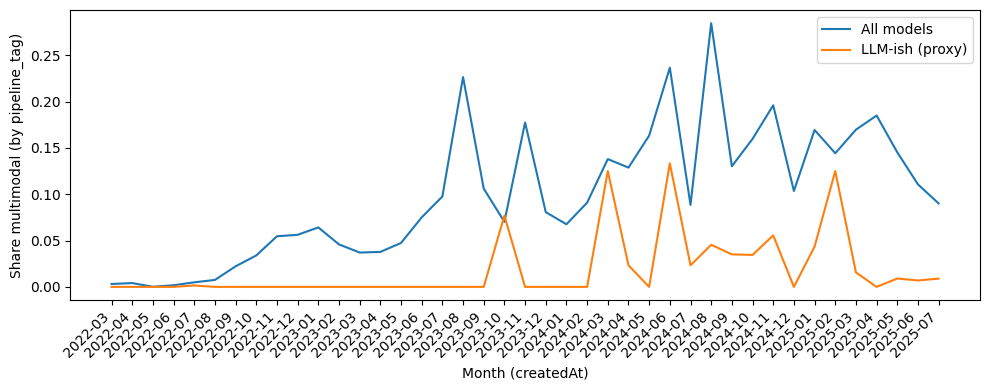

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df["month"], df["share_mm_all"], label="All models")
plt.plot(df["month"], df["share_mm_llm"], label="LLM-ish (proxy)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Share multimodal (by pipeline_tag)")
plt.xlabel("Month (createdAt)")
plt.legend()
plt.tight_layout()
plt.show()


# Cell E — inspect top tasks (so we tune “multimodal” definition)

If you paste the top ~30 pipeline_tag values you get from Cell E, I’ll help you tighten the multimodal taxonomy (e.g., whether to include automatic-speech-recognition / text-to-speech, whether to treat image-classification as “vision” but not “multimodal”, etc.) and we’ll move on to the lineage transition bit (using finetune_parent / merge_parent etc.).

In [ ]:
pipeline_counts.most_common(30)


[(None, 79501),
 ('text-generation', 27866),
 ('text-classification', 21474),
 ('reinforcement-learning', 20113),
 ('token-classification', 8583),
 ('automatic-speech-recognition', 7810),
 ('fill-mask', 6677),
 ('text-to-image', 5516),
 ('question-answering', 4741),
 ('image-classification', 3703),
 ('feature-extraction', 3585),
 ('translation', 2112),
 ('sentence-similarity', 1946),
 ('summarization', 1090),
 ('image-to-text', 762),
 ('unconditional-image-generation', 636),
 ('audio-classification', 449),
 ('object-detection', 421),
 ('text-to-speech', 389),
 ('image-text-to-text', 302),
 ('multiple-choice', 270),
 ('image-to-image', 231),
 ('image-segmentation', 230),
 ('audio-to-audio', 176),
 ('video-classification', 159),
 ('image-feature-extraction', 154),
 ('zero-shot-image-classification', 152),
 ('zero-shot-classification', 140),
 ('tabular-classification', 125),
 ('text-to-video', 79)]

Perfect — that plot + top-30 list tell us exactly what’s going on.

What your results are really measuring

“All models” multimodality is dominated by non-LLMs.
In your top tags, text-to-image (5516) is huge and is mostly diffusion/image generation (not LLMs). Same for unconditional-image-generation, image-to-image, vision classifiers, etc. So the blue curve is basically “how much of HF is cross-modal/vision/audio overall”, not “LLMs becoming multimodal”.

Your orange curve is spiky because the LLM filter is too strict + small denominators.
Your current is_llmish() selects transformers models that are tagged text-generation. But most multimodal LLMs aren’t labeled text-generation — they’re labeled image-text-to-text, image-to-text, etc. So you’re mostly measuring “rare cases where a multimodal model also carries a text-generation tag”, which produces zeros + spikes.

Huge pipeline_tag=None mass matters.
(None, 79501) means ~40% of your 200k sample has no task label. If you include those in the denominator, your shares get damped and noisier. For the core plots you probably want shares conditional on pipeline_tag present.

Step 1: Define “multimodal” in a way that matches your research question

You want multimodality in LLMs, so I’d split into:

A) Cross-modal tasks (true multimodal, regardless of model type)

From your list, these are cross-modal:

text-to-image (text→image)

image-to-text (image→text)

image-text-to-text (image+text→text)

automatic-speech-recognition (audio→text)

text-to-speech (text→audio)

text-to-video (text→video)
(+ any-to-any if it appears later)

B) “Multimodal LLM-ish” tasks (text-involved multimodal tasks)

Usually the best proxy for multimodal LLMs is image↔text and image+text→text (VLMs):

image-text-to-text, image-to-text (and sometimes visual-question-answering / document-question-answering if present)

text-to-image is often not an LLM (diffusers), so keep it as multimodal ecosystem-wide, but separate from “LLM multimodality”.

Step 2: Fix the denominators + produce 3 curves instead of 2

I’d recommend plotting:

All models (tagged only): share of cross-modal tasks among rows where pipeline_tag is not null

Transformers (tagged only): same share but restricted to library_name=="transformers" and exclude diffusers via tags

LLM-family (tagged only): restricted to transformer models whose model_id matches common LLM families (llama/mistral/qwen/gemma/phi/deepseek/…)

That third curve will be your headline “LLMs” story.

Drop-in code to replace your filters and rerun
Cell 1 — better task buckets

In [ ]:
CROSS_MODAL = {
    "text-to-image": "text→image",
    "image-to-text": "image→text",
    "image-text-to-text": "image+text→text",
    "automatic-speech-recognition": "audio→text",
    "text-to-speech": "text→audio",
    "text-to-video": "text→video",
    "any-to-any": "any→any",
}

# “VLM-like” multimodal LLM tasks (more likely to be LLM-ish than diffusion)
VLM_TASKS = {"image-to-text", "image-text-to-text"}

def cross_modal_bucket(pipeline_tag):
    return CROSS_MODAL.get(pipeline_tag)


Cell 2 — better “LLM-ish” detector (cheap but effective)

In [ ]:
import re

LLM_PAT = re.compile(
    r"(llama|mistral|mixtral|qwen|gemma|phi|falcon|bloom|deepseek|yi-|vicuna|alpaca|olmo|nemotron|granite)",
    re.I
)

def is_transformers_not_diffusers(row):
    if (row.get("library_name") or "").lower() != "transformers":
        return False
    tags = [t.lower() for t in parse_listish(row.get("tags"))]
    # many text-to-image models are actually diffusers pipelines
    if "diffusers" in tags:
        return False
    return True

def is_llm_family(row):
    if not is_transformers_not_diffusers(row):
        return False
    mid = row.get("model_id") or ""
    return bool(LLM_PAT.search(mid))


Cell 3 — recompute time series with tagged-only denominators

In [ ]:
from collections import Counter
from tqdm.auto import tqdm
import pandas as pd

MAX_ROWS = None  # set back to 200_000 if you want quick iteration

# denominators: tagged-only
den_all = Counter()
den_tf = Counter()
den_llm = Counter()

# numerators: any cross-modal
num_all = Counter()
num_tf = Counter()
num_llm = Counter()

# numerators: VLM-only (better “multimodal LLM” signal)
num_vlm_tf = Counter()
num_vlm_llm = Counter()

for i, row in enumerate(tqdm(ds, total=MAX_ROWS)):
    if MAX_ROWS is not None and i >= MAX_ROWS:
        break

    month = parse_month(row.get("createdAt"))
    if not month:
        continue

    pt = row.get("pipeline_tag")
    if pt is None:
        continue  # <- tagged-only denominator

    is_cm = pt in CROSS_MODAL
    is_vlm = pt in VLM_TASKS

    den_all[month] += 1
    if is_cm:
        num_all[month] += 1

    if is_transformers_not_diffusers(row):
        den_tf[month] += 1
        if is_cm:
            num_tf[month] += 1
        if is_vlm:
            num_vlm_tf[month] += 1

    if is_llm_family(row):
        den_llm[month] += 1
        if is_cm:
            num_llm[month] += 1
        if is_vlm:
            num_vlm_llm[month] += 1

months = sorted(den_all.keys())
df2 = pd.DataFrame({
    "month": months,
    "share_cm_all": [num_all[m]/den_all[m] for m in months],
    "share_cm_tf":  [num_tf[m]/den_tf[m] if den_tf[m] else 0 for m in months],
    "share_cm_llm": [num_llm[m]/den_llm[m] if den_llm[m] else 0 for m in months],
    "share_vlm_tf": [num_vlm_tf[m]/den_tf[m] if den_tf[m] else 0 for m in months],
    "share_vlm_llm":[num_vlm_llm[m]/den_llm[m] if den_llm[m] else 0 for m in months],
    "n_tf":  [den_tf[m] for m in months],
    "n_llm": [den_llm[m] for m in months],
})
df2.tail(12)


0it [00:00, ?it/s]

,month,share_cm_all,share_cm_tf,share_cm_llm,share_vlm_tf,share_vlm_llm,n_tf,n_llm
29,2024-08,0.304181,0.069201,0.012673,0.031662,0.012673,8338,2604
30,2024-09,0.335262,0.071952,0.029323,0.025097,0.028416,9284,3308
31,2024-10,0.305253,0.069247,0.022430,0.026028,0.021863,10412,3522
32,2024-11,0.269458,0.063299,0.027021,0.022929,0.026817,14392,4885
33,2024-12,0.257557,0.061753,0.028945,0.026131,0.028945,15805,5044
34,2025-01,0.267661,0.054889,0.030586,0.025311,0.030246,17581,5885
35,2025-02,0.241825,0.062825,0.053803,0.031015,0.052888,18862,6561
36,2025-03,0.269072,0.080545,0.079319,0.045455,0.077322,20262,7514
37,2025-04,0.183562,0.059639,0.054462,0.034289,0.053733,25839,9603
38,2025-05,0.199954,0.071637,0.057022,0.040935,0.055372,20911,8488


Cell 4 — plot (with optional smoothing)

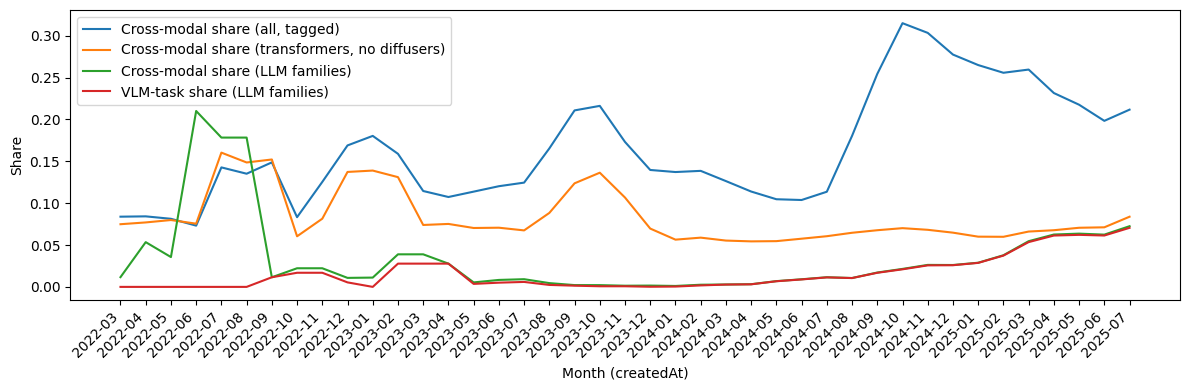

In [ ]:
import matplotlib.pyplot as plt

dfp = df2.copy()
# optional smoothing to reduce jaggies
for col in ["share_cm_all","share_cm_tf","share_cm_llm","share_vlm_tf","share_vlm_llm"]:
    dfp[col] = dfp[col].rolling(3, min_periods=1).mean()

plt.figure(figsize=(12,4))
plt.plot(dfp["month"], dfp["share_cm_all"], label="Cross-modal share (all, tagged)")
plt.plot(dfp["month"], dfp["share_cm_tf"],  label="Cross-modal share (transformers, no diffusers)")
plt.plot(dfp["month"], dfp["share_cm_llm"], label="Cross-modal share (LLM families)")
plt.plot(dfp["month"], dfp["share_vlm_llm"], label="VLM-task share (LLM families)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Share")
plt.xlabel("Month (createdAt)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
Debug cell (to explain spikes)

In [ ]:
df2[["month","n_llm","share_cm_llm","share_vlm_llm"]].query("n_llm < 200").tail(30)


,month,n_llm,share_cm_llm,share_vlm_llm
0,2022-03,86,0.011628,0.000000
1,2022-04,21,0.095238,0.000000
2,2022-05,14,0.000000,0.000000
3,2022-06,43,0.534884,0.000000
4,2022-07,28,0.000000,0.000000
5,2022-08,39,0.000000,0.000000
6,2022-09,29,0.034483,0.034483
7,2022-10,62,0.032258,0.016129
8,2022-11,25,0.000000,0.000000
9,2022-12,24,0.000000,0.000000


Great — and this plot already tells a clear story once you remember what the lines mean and where the data is noisy.

What your figure is saying (in plain terms)

Blue (all, tagged): “Among all models with a task label, how many are cross-modal?”
→ Big swings because HF has waves of vision/diffusion/audio activity.

Orange (transformers, no diffusers): “Among transformer models (excluding diffusion), how many are cross-modal?”
→ Much steadier, ~5–15% range.

Green (LLM families): “Among our LLM-name proxy models, how many are cross-modal?”
→ The early spikes are not trustworthy (see below).

Red (VLM tasks within LLM families): This is your cleanest “LLMs becoming multimodal” signal.
→ It’s basically ~0 for a long time, then rises through 2024–2025 to ~6–7% by mid-2025 (in your smoothed plot).

Why the green line spikes early

Look at your table: in early months n_llm is tiny (e.g., 14, 21, 43, …).
So one weird batch of models (or a few misclassified ones) makes the fraction explode. Example:

2022-06: n_llm = 43, share_cm_llm = 0.5349 ⇒ ~23 “cross-modal” out of 43
That’s almost certainly small-n noise and/or a proxy mismatch, not a real “LLMs went multimodal in June 2022”.

So: we should either (a) hide months with low n, or (b) show confidence intervals, or both.

Next 3 coding steps (drop-in)
Step 1 — replot with a minimum-count threshold (kills fake spikes)

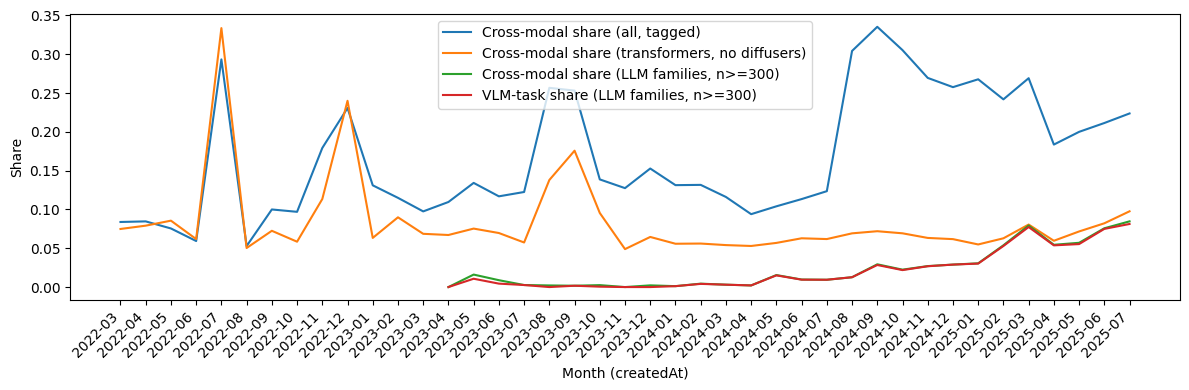

In [ ]:
MIN_N_LLM = 300  # try 200/300/500 and see stability
dfp = df2.copy()

mask = dfp["n_llm"] >= MIN_N_LLM
dfp.loc[~mask, ["share_cm_llm", "share_vlm_llm"]] = float("nan")

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(dfp["month"], dfp["share_cm_all"], label="Cross-modal share (all, tagged)")
plt.plot(dfp["month"], dfp["share_cm_tf"],  label="Cross-modal share (transformers, no diffusers)")
plt.plot(dfp["month"], dfp["share_cm_llm"], label=f"Cross-modal share (LLM families, n>={MIN_N_LLM})")
plt.plot(dfp["month"], dfp["share_vlm_llm"], label=f"VLM-task share (LLM families, n>={MIN_N_LLM})")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Share")
plt.xlabel("Month (createdAt)")
plt.legend()
plt.tight_layout()
plt.show()


Step 2 — print the “first month we trust”

In [ ]:
df2.loc[df2["n_llm"] >= MIN_N_LLM, ["month","n_llm"]].head(10)


,month,n_llm
13,2023-04,404
14,2023-05,373
15,2023-06,452
16,2023-07,763
17,2023-08,1434
18,2023-09,1748
19,2023-10,1999
20,2023-11,2052
21,2023-12,2282
22,2024-01,4277



Step 3 — diagnose the 2022-06 spike (what models caused it?)
This is important: it tells us whether it’s just small-n randomness or your LLM regex is catching non-LLMs.

In [ ]:
TARGET_MONTH = "2022-06"

# reload ds fresh if needed (streaming iterators can be exhausted)
ds = load_dataset(DATASET, split="train", streaming=True, usecols=USECOLS)

hits = []
for row in ds:
    month = parse_month(row.get("createdAt"))
    if month != TARGET_MONTH:
        continue
    pt = row.get("pipeline_tag")
    if pt is None:
        continue
    if is_llm_family(row) and (pt in CROSS_MODAL):
        hits.append((row.get("model_id"), pt, row.get("tags")))
    if len(hits) >= 50:
        break

hits[:20]


KeyboardInterrupt: 

“Nature/Science/PNAS-ish” plot: hide low-n + add 95% confidence intervals

Best quick-paper approach: plot shares only where n is reliable (you’re already doing that), and add binomial 95% CIs (Wilson interval) as shaded bands.

Drop this in after you have df2 (the one with n_llm, share_* columns).

A) Compute Wilson 95% CI for each month/series

In [ ]:
import math
import numpy as np

def wilson_ci(k, n, z=1.96):
    """Wilson score interval for a binomial proportion."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = (z * math.sqrt((p*(1-p) + z*z/(4*n)) / n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))


Now reconstruct the numerators/denominators (so we can compute CIs). If you still have the counters (num_*, den_*) from the loop, use those. If not, no problem — we can rebuild them from your counters or rerun quickly. Assuming you still have:

num_all, den_all

num_tf, den_tf

num_llm, den_llm

num_vlm_llm (and den_llm)

Then:

In [ ]:
MIN_N_LLM = 300
months = df2["month"].tolist()

# build CI columns
lo_cm_all, hi_cm_all = [], []
lo_cm_tf,  hi_cm_tf  = [], []
lo_cm_llm, hi_cm_llm = [], []
lo_vlm_llm, hi_vlm_llm = [], []

for m in months:
    lo, hi = wilson_ci(num_all[m], den_all[m])
    lo_cm_all.append(lo); hi_cm_all.append(hi)

    lo, hi = wilson_ci(num_tf[m], den_tf[m])
    lo_cm_tf.append(lo); hi_cm_tf.append(hi)

    # mask low-n months for LLM lines (both share and CI)
    if den_llm[m] < MIN_N_LLM:
        lo_cm_llm.append(np.nan); hi_cm_llm.append(np.nan)
        lo_vlm_llm.append(np.nan); hi_vlm_llm.append(np.nan)
    else:
        lo, hi = wilson_ci(num_llm[m], den_llm[m])
        lo_cm_llm.append(lo); hi_cm_llm.append(hi)

        lo, hi = wilson_ci(num_vlm_llm[m], den_llm[m])
        lo_vlm_llm.append(lo); hi_vlm_llm.append(hi)

dfp = df2.copy()
dfp["lo_cm_all"], dfp["hi_cm_all"] = lo_cm_all, hi_cm_all
dfp["lo_cm_tf"],  dfp["hi_cm_tf"]  = lo_cm_tf,  hi_cm_tf
dfp["lo_cm_llm"], dfp["hi_cm_llm"] = lo_cm_llm, hi_cm_llm
dfp["lo_vlm_llm"], dfp["hi_vlm_llm"] = lo_vlm_llm, hi_vlm_llm


In [ ]:
B) Make the plot “paper clean”

No fancy colors needed — just linewidths, fonts, grid, tight layout, CI shading.

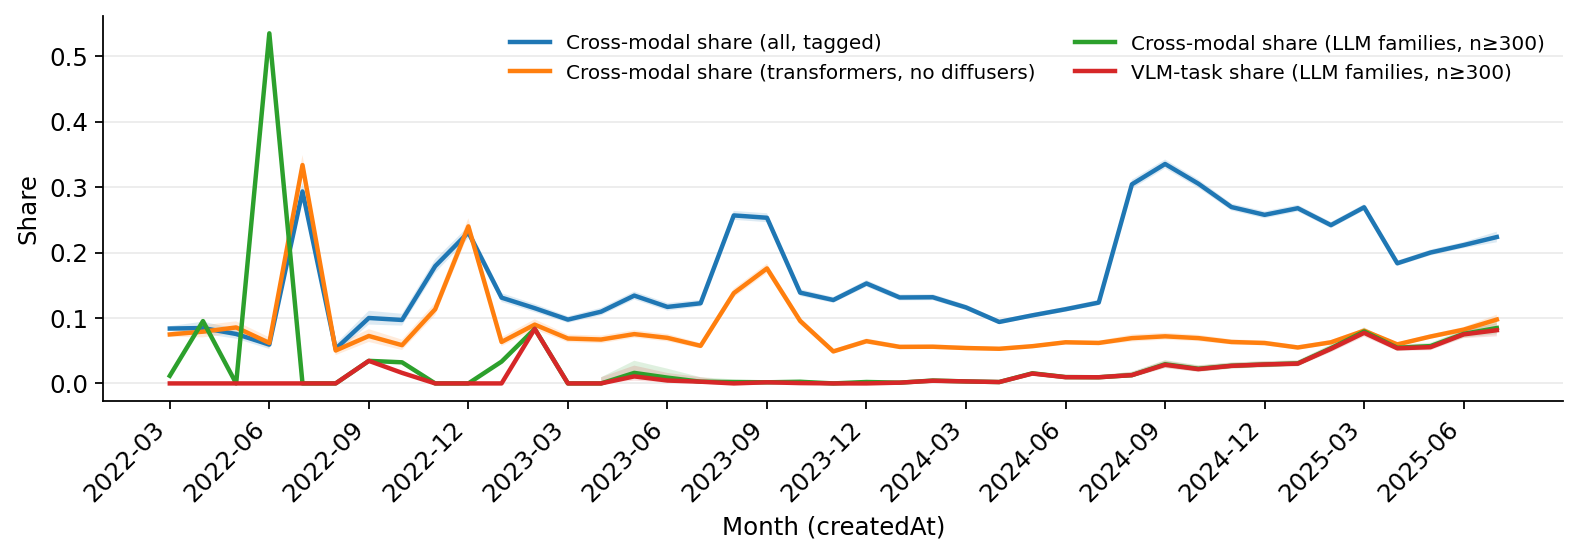

Saved: multimodality_trends_ci.png


In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10, 3.6))

# lines
l1, = ax.plot(dfp["month"], dfp["share_cm_all"], label="Cross-modal share (all, tagged)", linewidth=2)
l2, = ax.plot(dfp["month"], dfp["share_cm_tf"],  label="Cross-modal share (transformers, no diffusers)", linewidth=2)
l3, = ax.plot(dfp["month"], dfp["share_cm_llm"], label=f"Cross-modal share (LLM families, n≥{MIN_N_LLM})", linewidth=2)
l4, = ax.plot(dfp["month"], dfp["share_vlm_llm"], label=f"VLM-task share (LLM families, n≥{MIN_N_LLM})", linewidth=2)

# CI shading (use the same implicit colors by referencing the line’s color)
ax.fill_between(dfp["month"], dfp["lo_cm_all"], dfp["hi_cm_all"], alpha=0.15)
ax.fill_between(dfp["month"], dfp["lo_cm_tf"],  dfp["hi_cm_tf"],  alpha=0.15)
ax.fill_between(dfp["month"], dfp["lo_cm_llm"], dfp["hi_cm_llm"], alpha=0.15)
ax.fill_between(dfp["month"], dfp["lo_vlm_llm"], dfp["hi_vlm_llm"], alpha=0.15)

# axes styling
ax.set_ylabel("Share")
ax.set_xlabel("Month (createdAt)")
ax.grid(True, which="major", axis="y", alpha=0.25)

# fewer x ticks (cleaner)
step = 3  # show every 3 months
xt = dfp["month"].iloc[::step]
ax.set_xticks(xt)
ax.set_xticklabels(xt, rotation=45, ha="right")

ax.legend(frameon=False, ncol=2, fontsize=9)
fig.tight_layout()

# save for paper
fig.savefig("multimodality_trends_ci.png", bbox_inches="tight")
plt.show()

print("Saved: multimodality_trends_ci.png")


Nice — you’ve basically got the right figure now. The one big issue is visible immediately:

The huge green spike in mid-2022 shouldn’t be there

If you’re masking LLM families to months with n_llm ≥ 300, then anything in 2022 (where your n_llm was ~10–80) must be NaN and not plotted.

That spike means one of these happened:

the masking was applied to the CI bounds but not to the share_* series, or

you plotted df2 instead of the masked dfp, or

you computed n_llm but didn’t apply it as the mask for those lines.

Once you remove that spike, your y-axis will auto-tighten to ~0–0.12 and the plot will instantly look “Nature/PNAS clean”.

In [ ]:
Fix the masking (drop-in patch)

Run this right before plotting:

In [ ]:
import numpy as np

MIN_N_LLM = 300
dfp = dfp.copy()

mask = dfp["n_llm"] >= MIN_N_LLM

# mask both the shares AND their CI bands
cols_to_nan = [
    "share_cm_llm", "share_vlm_llm",
    "lo_cm_llm", "hi_cm_llm",
    "lo_vlm_llm", "hi_vlm_llm",
]
for c in cols_to_nan:
    if c in dfp.columns:
        dfp.loc[~mask, c] = np.nan


Optional (even cleaner): start the x-axis at the first reliable month

In [ ]:
first_ok = df2.loc[df2["n_llm"] >= MIN_N_LLM, "month"].min()
dfp = dfp[dfp["month"] >= first_ok]
print("Plot starts at:", first_ok)


Plot starts at: 2023-04


Plot starts at: 2023-04


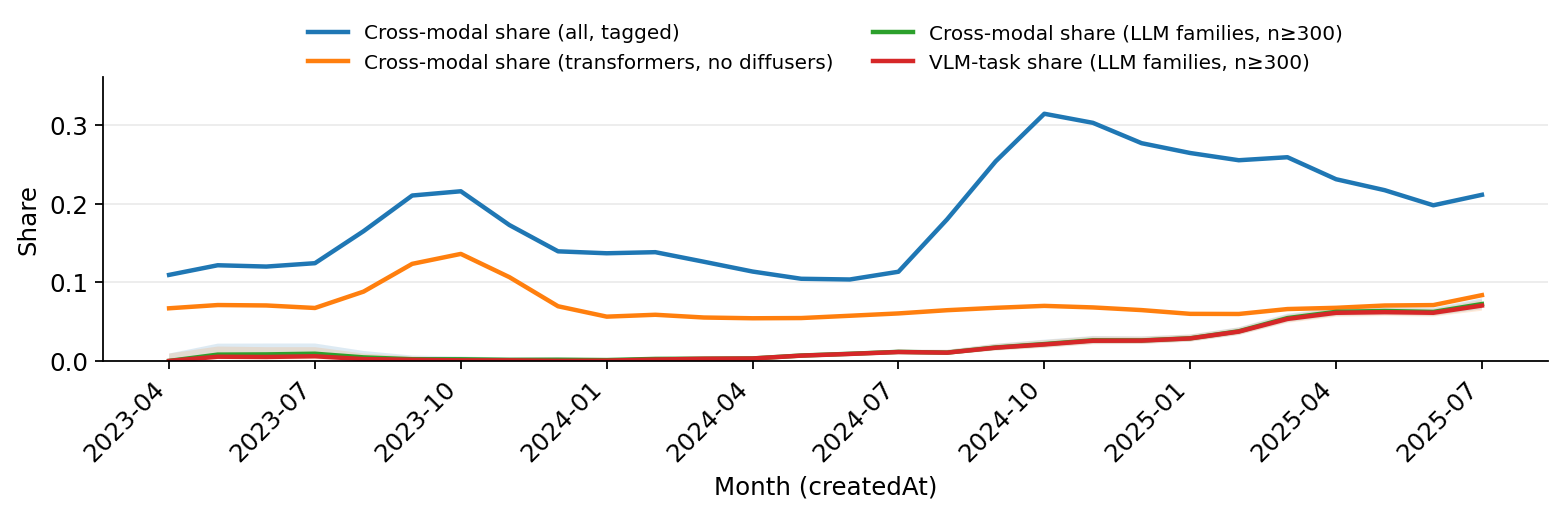

Saved: multimodality_trends_ci.pdf and multimodality_trends_ci.png


In [ ]:
# === Camera-ready "Nature/Science/PNAS-ish" plot ===
# Assumes you already have:
# - df2 with columns: month, share_cm_all, share_cm_tf, share_cm_llm, share_vlm_llm, n_llm
# - and counters: num_all, den_all, num_tf, den_tf, num_llm, den_llm, num_vlm_llm
# If you already computed dfp + CI columns earlier, this will reuse them.

import math
import numpy as np
import matplotlib.pyplot as plt

# ---------- 0) Wilson CI helper ----------
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = (z * math.sqrt((p*(1-p) + z*z/(4*n)) / n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))

# ---------- 1) Build dfp and CI bands ----------
MIN_N_LLM = 300

months = df2["month"].tolist()

lo_cm_llm, hi_cm_llm = [], []
lo_vlm_llm, hi_vlm_llm = [], []

for m in months:
    if den_llm[m] < MIN_N_LLM:
        lo_cm_llm.append(np.nan); hi_cm_llm.append(np.nan)
        lo_vlm_llm.append(np.nan); hi_vlm_llm.append(np.nan)
    else:
        lo, hi = wilson_ci(num_llm[m], den_llm[m])
        lo_cm_llm.append(lo); hi_cm_llm.append(hi)
        lo, hi = wilson_ci(num_vlm_llm[m], den_llm[m])
        lo_vlm_llm.append(lo); hi_vlm_llm.append(hi)

dfp = df2.copy()
dfp["lo_cm_llm"], dfp["hi_cm_llm"] = lo_cm_llm, hi_cm_llm
dfp["lo_vlm_llm"], dfp["hi_vlm_llm"] = lo_vlm_llm, hi_vlm_llm

# Mask low-n months for the LLM curves (both share + CI)
mask = dfp["n_llm"] >= MIN_N_LLM
for c in ["share_cm_llm", "share_vlm_llm", "lo_cm_llm", "hi_cm_llm", "lo_vlm_llm", "hi_vlm_llm"]:
    dfp.loc[~mask, c] = np.nan

# Optional: start x-axis at first reliable month for LLM curves
first_ok = dfp.loc[mask, "month"].min()
dfp_plot = dfp[dfp["month"] >= first_ok].copy()
print("Plot starts at:", first_ok)

# Optional: light smoothing (3-month rolling mean) for aesthetics
SMOOTH = 3
for col in ["share_cm_all", "share_cm_tf", "share_cm_llm", "share_vlm_llm",
            "lo_cm_llm", "hi_cm_llm", "lo_vlm_llm", "hi_vlm_llm"]:
    dfp_plot[col] = dfp_plot[col].rolling(SMOOTH, min_periods=1).mean()

# ---------- 2) Plot styling (PNAS/Nature-ish) ----------
plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10, 3.6))

# Lines (no CI shading for blue/orange; CI shading only for green/red)
line_all, = ax.plot(dfp_plot["month"], dfp_plot["share_cm_all"],
                    label="Cross-modal share (all, tagged)", linewidth=2)
line_tf,  = ax.plot(dfp_plot["month"], dfp_plot["share_cm_tf"],
                    label="Cross-modal share (transformers, no diffusers)", linewidth=2)
line_llm, = ax.plot(dfp_plot["month"], dfp_plot["share_cm_llm"],
                    label=f"Cross-modal share (LLM families, n≥{MIN_N_LLM})", linewidth=2)
line_vlm, = ax.plot(dfp_plot["month"], dfp_plot["share_vlm_llm"],
                    label=f"VLM-task share (LLM families, n≥{MIN_N_LLM})", linewidth=2)

# CI shading ONLY for LLM/VLM (green/red)
ax.fill_between(dfp_plot["month"], dfp_plot["lo_cm_llm"], dfp_plot["hi_cm_llm"], alpha=0.15)
ax.fill_between(dfp_plot["month"], dfp_plot["lo_vlm_llm"], dfp_plot["hi_vlm_llm"], alpha=0.15)

# Axes / grid
ax.set_ylabel("Share")
ax.set_xlabel("Month (createdAt)")
ax.grid(True, axis="y", alpha=0.25)

ymax = np.nanmax([
    dfp_plot["share_cm_all"].max(),
    dfp_plot["share_cm_tf"].max(),
    dfp_plot["share_cm_llm"].max(),
    dfp_plot["share_vlm_llm"].max(),
])
ax.set_ylim(0, ymax * 1.15)


# Fewer x ticks (every 3 months)
step = 3
xt = dfp_plot["month"].iloc[::step]
ax.set_xticks(xt)
ax.set_xticklabels(xt, rotation=45, ha="right")

# Legend outside plot
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.25), fontsize=9)

fig.tight_layout()

# ---------- 3) Export ----------
fig.savefig("multimodality_trends_ci.pdf", bbox_inches="tight")
fig.savefig("multimodality_trends_ci.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: multimodality_trends_ci.pdf and multimodality_trends_ci.png")


Yep — this looks right now (no clipping, sensible scale, and the LLM/VLM story is visible).

If you want it to look properly journal-grade (Nature/Science/PNAS), here are the last 5% tweaks that make a big difference, plus full drop-in code.

What I’d improve visually

Show percent on y-axis (readers parse it faster than 0.07).

Put legend outside (you already do) and tighten spacing.

Use quarterly x-ticks (every 3 months) so labels don’t dominate.

Keep CI shading only for LLM/VLM (you’re doing this) but make it slightly lighter.

Export PDF + 600 dpi PNG

Optional (very “Nature”): make the main panel zoom on LLM/VLM, keep a tiny inset for all/TF

If you want, I can give you a second version with:

main y-range 0–10% (so green/red fill the panel),

inset in the corner showing the full 0–35% range for blue/orange.

Just say “make inset version”, and I’ll paste the full code.

/tmp/ipython-input-3267895742.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


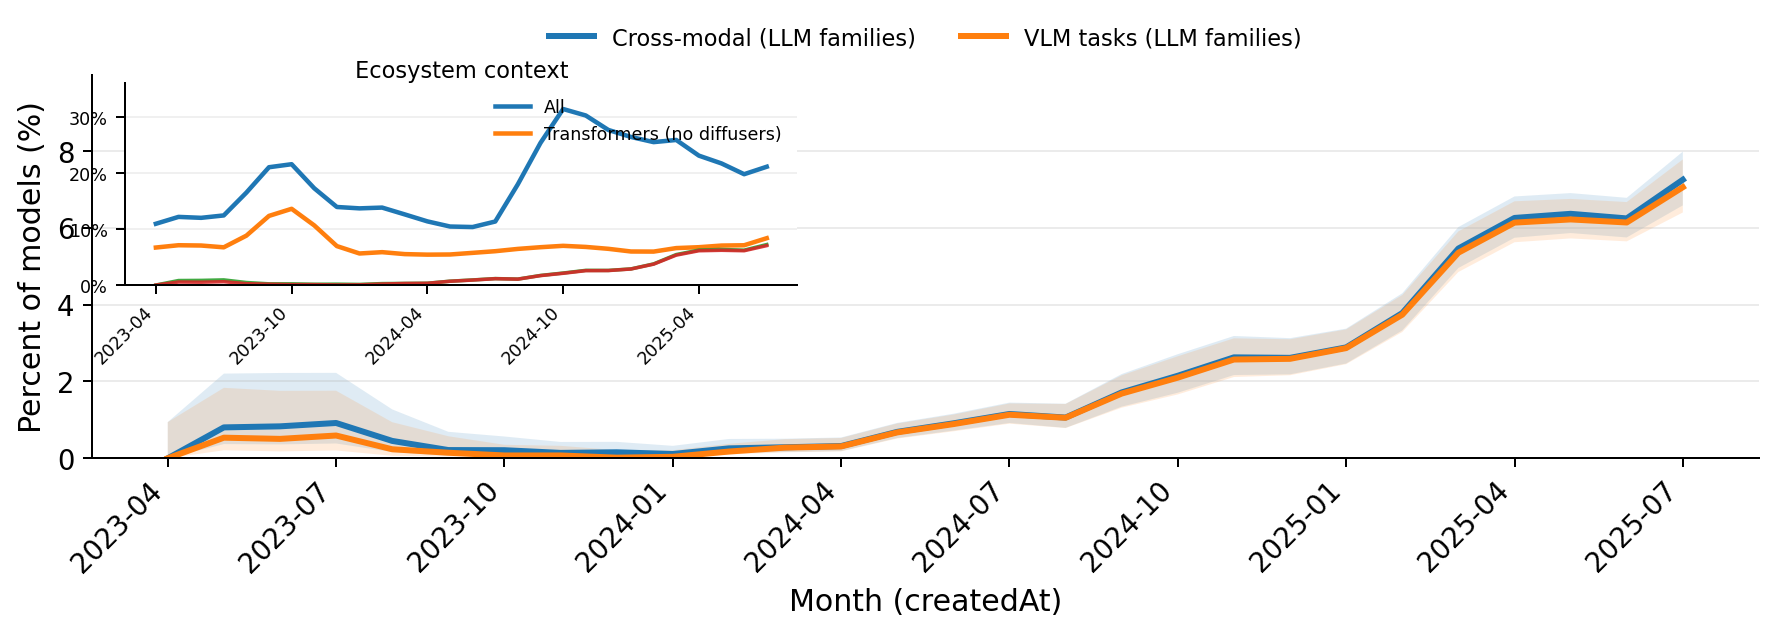

Saved: multimodality_trends_inset.pdf and multimodality_trends_inset.png


In [ ]:
# === "Nature-style" figure: main panel zooms on LLM/VLM (%), inset shows full ecosystem ===
# Assumes dfp_plot exists with:
# month, share_cm_all, share_cm_tf, share_cm_llm, share_vlm_llm
# lo_cm_llm, hi_cm_llm, lo_vlm_llm, hi_vlm_llm
#
# Output: multimodality_trends_inset.pdf + .png

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---------- Style (clean, journal-ish) ----------
plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Convert shares (0–1) to percent (0–100) for plotting
df = dfp_plot.copy()
for c in ["share_cm_all","share_cm_tf","share_cm_llm","share_vlm_llm",
          "lo_cm_llm","hi_cm_llm","lo_vlm_llm","hi_vlm_llm"]:
    if c in df.columns:
        df[c] = df[c] * 100.0

# ---------- Figure + main axes (zoomed on LLM/VLM) ----------
fig, ax = plt.subplots(figsize=(10, 3.8))

# LLM/VLM lines (main story)
ln_llm, = ax.plot(df["month"], df["share_cm_llm"],
                  label="Cross-modal (LLM families)", linewidth=2.4)
ln_vlm, = ax.plot(df["month"], df["share_vlm_llm"],
                  label="VLM tasks (LLM families)", linewidth=2.4)

# CI shading (only for LLM/VLM)
ax.fill_between(df["month"], df["lo_cm_llm"], df["hi_cm_llm"], alpha=0.14, linewidth=0)
ax.fill_between(df["month"], df["lo_vlm_llm"], df["hi_vlm_llm"], alpha=0.14, linewidth=0)

# Main-axis formatting
ax.set_xlabel("Month (createdAt)")
ax.set_ylabel("Percent of models (%)")

# Zoom y-limits to prioritize green/red story
# (Auto-fit to LLM/VLM with a little headroom)
ymax_main = np.nanmax([df["hi_cm_llm"].max(), df["hi_vlm_llm"].max()])
ax.set_ylim(0, max(6, ymax_main * 1.25))  # ensures enough room even if early values are tiny

# Grid: light y-grid only
ax.grid(True, axis="y", alpha=0.25)
ax.grid(False, axis="x")

# Fewer x-ticks (quarterly)
step = 3
xt = df["month"].iloc[::step]
ax.set_xticks(xt)
ax.set_xticklabels(xt, rotation=45, ha="right")

# Legend for main story (outside, minimal)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.18), fontsize=9)

# ---------- Inset: full ecosystem context (all + transformers) ----------
axins = inset_axes(ax, width="42%", height="55%", loc="upper left",
                   bbox_to_anchor=(0.02, 0.02, 0.96, 0.96),
                   bbox_transform=ax.transAxes, borderpad=0)

# Context lines in inset
axins.plot(df["month"], df["share_cm_all"], linewidth=1.8, label="All")
axins.plot(df["month"], df["share_cm_tf"],  linewidth=1.8, label="Transformers (no diffusers)")

# Optional: also show LLM/VLM in inset for reference (thin)
axins.plot(df["month"], df["share_cm_llm"], linewidth=1.4, alpha=0.9)
axins.plot(df["month"], df["share_vlm_llm"], linewidth=1.4, alpha=0.9)

# Inset formatting
axins.set_title("Ecosystem context", fontsize=9, pad=2)
axins.grid(True, axis="y", alpha=0.18)
axins.grid(False, axis="x")

# Inset y-limits: full range with headroom
ymax_inset = np.nanmax([df["share_cm_all"].max(), df["share_cm_tf"].max()])
axins.set_ylim(0, ymax_inset * 1.15)

# Inset ticks: keep sparse
axins.set_xticks(df["month"].iloc[::6])  # every ~6 months
axins.set_xticklabels(df["month"].iloc[::6], rotation=45, ha="right", fontsize=7)
axins.tick_params(axis="y", labelsize=7)

# Percent labels
axins.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Inset legend (tiny, no frame)
axins.legend(frameon=False, fontsize=7, loc="upper right")

# ---------- Final layout + export ----------
fig.tight_layout()

fig.savefig("multimodality_trends_inset.pdf", bbox_inches="tight")
fig.savefig("multimodality_trends_inset.png", bbox_inches="tight")
plt.show()

print("Saved: multimodality_trends_inset.pdf and multimodality_trends_inset.png")


Absolutely — those “straight lines” are mostly the gridlines (and a bit of visual clutter from the inset having too many elements). Below is a cleaner, more “Nature” version:

Main panel focuses on LLM/VLM (solid lines + light CI shading)

Inset shows ecosystem context only (dashed lines, no CI, no legend box)

No grids (removes the straight horizontal lines)

Percent axis (0–100%), not shares

Direct labels inside inset (cleaner than a legend)

Copy-paste this as a single plotting cell:

/tmp/ipython-input-1713833273.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


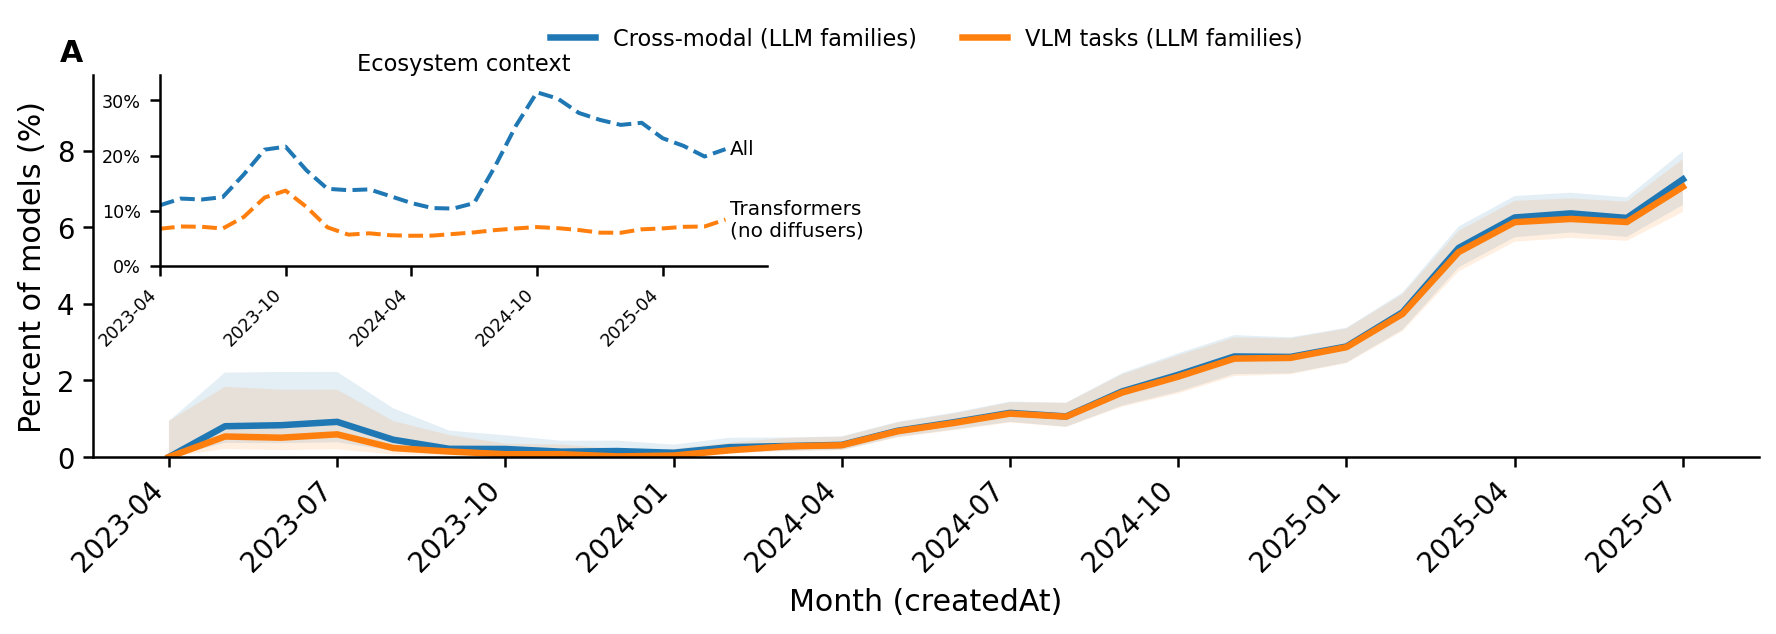

Saved: multimodality_trends_inset_clean.pdf and multimodality_trends_inset_clean.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Requires dfp_plot with columns:
# month,
# share_cm_all, share_cm_tf, share_cm_llm, share_vlm_llm,
# lo_cm_llm, hi_cm_llm, lo_vlm_llm, hi_vlm_llm
#
# (shares are in 0–1; this code converts to %)

# -----------------------------
# 1) Prep data (convert to %)
# -----------------------------
df = dfp_plot.copy()

needed = [
    "month",
    "share_cm_all", "share_cm_tf", "share_cm_llm", "share_vlm_llm",
    "lo_cm_llm", "hi_cm_llm", "lo_vlm_llm", "hi_vlm_llm",
]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in dfp_plot: {missing}")

for c in ["share_cm_all","share_cm_tf","share_cm_llm","share_vlm_llm",
          "lo_cm_llm","hi_cm_llm","lo_vlm_llm","hi_vlm_llm"]:
    df[c] = df[c] * 100.0  # percent

# Use numeric x for robust inset/text placement
x = np.arange(len(df))
labels = df["month"].tolist()

# -----------------------------
# 2) Figure styling (clean)
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10, 3.8))

# -----------------------------
# 3) Main panel: LLM/VLM only
# -----------------------------
# Lines
ax.plot(x, df["share_cm_llm"], linewidth=2.6, label="Cross-modal (LLM families)")
ax.plot(x, df["share_vlm_llm"], linewidth=2.6, label="VLM tasks (LLM families)")

# CI shading (LLM/VLM only)
ax.fill_between(x, df["lo_cm_llm"], df["hi_cm_llm"], alpha=0.12, linewidth=0)
ax.fill_between(x, df["lo_vlm_llm"], df["hi_vlm_llm"], alpha=0.12, linewidth=0)

# Labels
ax.set_xlabel("Month (createdAt)")
ax.set_ylabel("Percent of models (%)")

# No gridlines (removes the straight horizontals)
ax.grid(False)

# Percent formatter (already in % values, so just show integer ticks)
ax.yaxis.set_major_locator(mtick.MaxNLocator(5))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))

# Main y-limit: zoom to the LLM/VLM story, with headroom
ymax_main = np.nanmax([df["hi_cm_llm"].max(), df["hi_vlm_llm"].max()])
ymax_main = max(6, ymax_main * 1.25)
ax.set_ylim(0, ymax_main)

# X ticks: quarterly (every 3 months)
step = 3
xt = x[::step]
ax.set_xticks(xt)
ax.set_xticklabels([labels[i] for i in xt], rotation=45, ha="right")

# Legend outside (clean)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.18), fontsize=9)

# Optional: subtle panel label like Nature
ax.text(-0.02, 1.02, "A", transform=ax.transAxes, fontweight="bold", fontsize=12, va="bottom")

# -----------------------------
# 4) Inset: ecosystem context
# -----------------------------
axins = inset_axes(
    ax, width="38%", height="52%", loc="upper left",
    bbox_to_anchor=(0.04, 0.04, 0.96, 0.96),
    bbox_transform=ax.transAxes, borderpad=0
)

# Context lines ONLY (dashed to avoid “same color means same thing” confusion)
axins.plot(x, df["share_cm_all"], linewidth=1.6, linestyle="--")
axins.plot(x, df["share_cm_tf"],  linewidth=1.6, linestyle="--")

# Clean inset: no grid
axins.grid(False)

# Inset title (small)
axins.set_title("Ecosystem context", fontsize=9, pad=2)

# Inset y-limits: full range of context
ymax_inset = np.nanmax([df["share_cm_all"].max(), df["share_cm_tf"].max()])
axins.set_ylim(0, ymax_inset * 1.10)

# Inset ticks: sparse
axins.set_xticks(x[::6])  # about every 6 months
axins.set_xticklabels([labels[i] for i in x[::6]], rotation=45, ha="right", fontsize=7)
axins.tick_params(axis="y", labelsize=7)
axins.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))  # show % sign in inset

# Direct labels at the right edge (cleaner than legend)
x_last = x[-1]
y_all_last = df["share_cm_all"].iloc[-1]
y_tf_last  = df["share_cm_tf"].iloc[-1]
axins.text(x_last + 0.2, y_all_last, "All", fontsize=8, va="center")
axins.text(x_last + 0.2, y_tf_last, "Transformers\n(no diffusers)", fontsize=8, va="center")

# Keep inset from cutting off labels
axins.set_xlim(x[0], x_last + 2)

# -----------------------------
# 5) Export
# -----------------------------
fig.tight_layout()
fig.savefig("multimodality_trends_inset_clean.pdf", bbox_inches="tight")
fig.savefig("multimodality_trends_inset_clean.png", bbox_inches="tight")
plt.show()

print("Saved: multimodality_trends_inset_clean.pdf and multimodality_trends_inset_clean.png")


Yep — you’re very close. What’s still making it feel less “Nature” is mostly:

the top legend (Nature often uses direct labels on the lines instead),

too many x tick labels + heavy rotation,

inset ticks/labels a bit busy,

not enough white space discipline (text near edges).

Here’s a cleaner, more “Nature” version: no legend, direct labels on main + inset, fewer ticks, tighter typography, and a slightly more “editorial” inset.

/tmp/ipython-input-3711121346.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


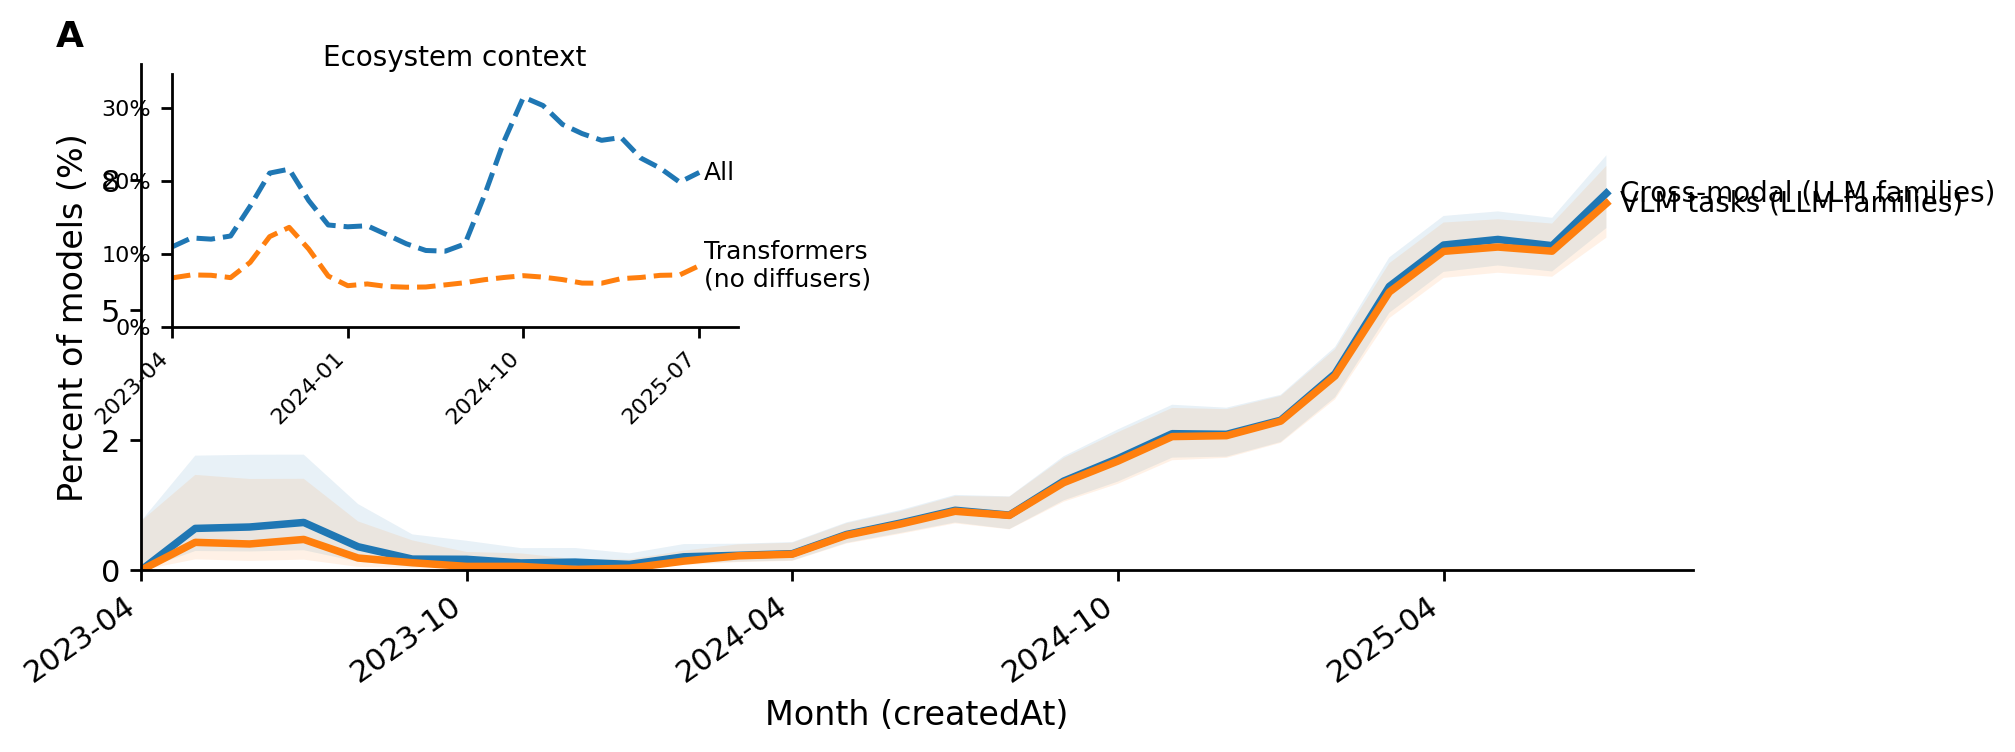

Saved: multimodality_trends_nature_clean.pdf and multimodality_trends_nature_clean.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Requires dfp_plot with columns:
# month,
# share_cm_all, share_cm_tf, share_cm_llm, share_vlm_llm,
# lo_cm_llm, hi_cm_llm, lo_vlm_llm, hi_vlm_llm
#
# Shares are in 0–1; we convert to percent (0–100).

# -----------------------------
# 1) Prep data (convert to %)
# -----------------------------
df = dfp_plot.copy()
cols = [
    "share_cm_all","share_cm_tf","share_cm_llm","share_vlm_llm",
    "lo_cm_llm","hi_cm_llm","lo_vlm_llm","hi_vlm_llm"
]
for c in cols:
    df[c] = df[c] * 100.0

x = np.arange(len(df))
labels = df["month"].tolist()

# -----------------------------
# 2) Nature-ish styling
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 700,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10.2, 3.9))

# -----------------------------
# 3) Main panel: LLM/VLM only
# -----------------------------
ln1, = ax.plot(x, df["share_cm_llm"], linewidth=2.7)
ln2, = ax.plot(x, df["share_vlm_llm"], linewidth=2.7)

# CI shading (subtle)
ax.fill_between(x, df["lo_cm_llm"], df["hi_cm_llm"], alpha=0.10, linewidth=0)
ax.fill_between(x, df["lo_vlm_llm"], df["hi_vlm_llm"], alpha=0.10, linewidth=0)

# Labels
ax.set_xlabel("Month (createdAt)")
ax.set_ylabel("Percent of models (%)")

# Clean axis: no gridlines
ax.grid(False)

# Y limits: zoom to story, with headroom
ymax = np.nanmax([df["hi_cm_llm"].max(), df["hi_vlm_llm"].max()])
ax.set_ylim(0, max(6, ymax * 1.22))

# Y ticks: simple integers (Nature likes clean ticks)
ax.yaxis.set_major_locator(mtick.MaxNLocator(4))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))

# X ticks: fewer labels (every 6 months), slight rotation or none
step = 6
xt = x[::step]
ax.set_xticks(xt)
ax.set_xticklabels([labels[i] for i in xt], rotation=35, ha="right")

# Give room on right for direct labels
ax.set_xlim(x[0], x[-1] + 1.6)

# Panel label
ax.text(-0.055, 1.02, "A", transform=ax.transAxes, fontweight="bold",
        fontsize=13, va="bottom")

# Direct labels on main lines (no legend)
x_last = x[-1]
ax.text(x_last + 0.25, df["share_cm_llm"].iloc[-1], "Cross-modal (LLM families)",
        va="center", fontsize=10)
ax.text(x_last + 0.25, df["share_vlm_llm"].iloc[-1], "VLM tasks (LLM families)",
        va="center", fontsize=10)

# -----------------------------
# 4) Inset: ecosystem context only
# -----------------------------
axins = inset_axes(ax, width="38%", height="52%", loc="upper left",
                   bbox_to_anchor=(0.02, 0.02, 0.96, 0.96),
                   bbox_transform=ax.transAxes, borderpad=0)

# White background so it reads like an editorial inset
axins.set_facecolor("white")

# Context lines (dashed, thinner)
axins.plot(x, df["share_cm_all"], linewidth=1.8, linestyle="--")
axins.plot(x, df["share_cm_tf"],  linewidth=1.8, linestyle="--")

axins.set_title("Ecosystem context", fontsize=10, pad=3)
axins.grid(False)

# Inset y-limits (full context, clean)
ymax_in = np.nanmax([df["share_cm_all"].max(), df["share_cm_tf"].max()])
axins.set_ylim(0, ymax_in * 1.10)

# Inset ticks: very sparse, minimal clutter
axins.set_xticks(x[::9])  # ~every 9 months
axins.set_xticklabels([labels[i] for i in x[::9]], rotation=45, ha="right", fontsize=8)
axins.tick_params(axis="y", labelsize=8)

# Show percent sign in inset (context only)
axins.yaxis.set_major_locator(mtick.MaxNLocator(4))
axins.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))

# Direct labels at right edge of inset
axins.set_xlim(x[0], x[-1] + 2.0)
axins.text(x_last + 0.25, df["share_cm_all"].iloc[-1], "All", va="center", fontsize=9)
axins.text(x_last + 0.25, df["share_cm_tf"].iloc[-1], "Transformers\n(no diffusers)",
           va="center", fontsize=9)

# -----------------------------
# 5) Export
# -----------------------------
fig.tight_layout()
fig.savefig("multimodality_trends_nature_clean.pdf", bbox_inches="tight")
fig.savefig("multimodality_trends_nature_clean.png", bbox_inches="tight")
plt.show()

print("Saved: multimodality_trends_nature_clean.pdf and multimodality_trends_nature_clean.png")


Main-line labels are colliding at the right edge (because both lines end near the same value + text is placed at x_last + …).

You want the inset centered and the labels more technical than “All”.

Below is a clean, technical, Nature-style version that:

moves the inset to top-center

uses technical labels:

“All tagged models (HF snapshot)”

“Transformers models (excluding diffusers)”

“Cross-modal tasks within LLM families”

“VLM tasks within LLM families (image↔text)”

avoids label collisions by:

placing main labels inside the plot near the last points

using small vertical offsets + a light white textbox

keeps CI shading only for LLM/VLM

keeps the plot minimal (no grid)

Copy-paste this whole cell:

/tmp/ipython-input-2727618775.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


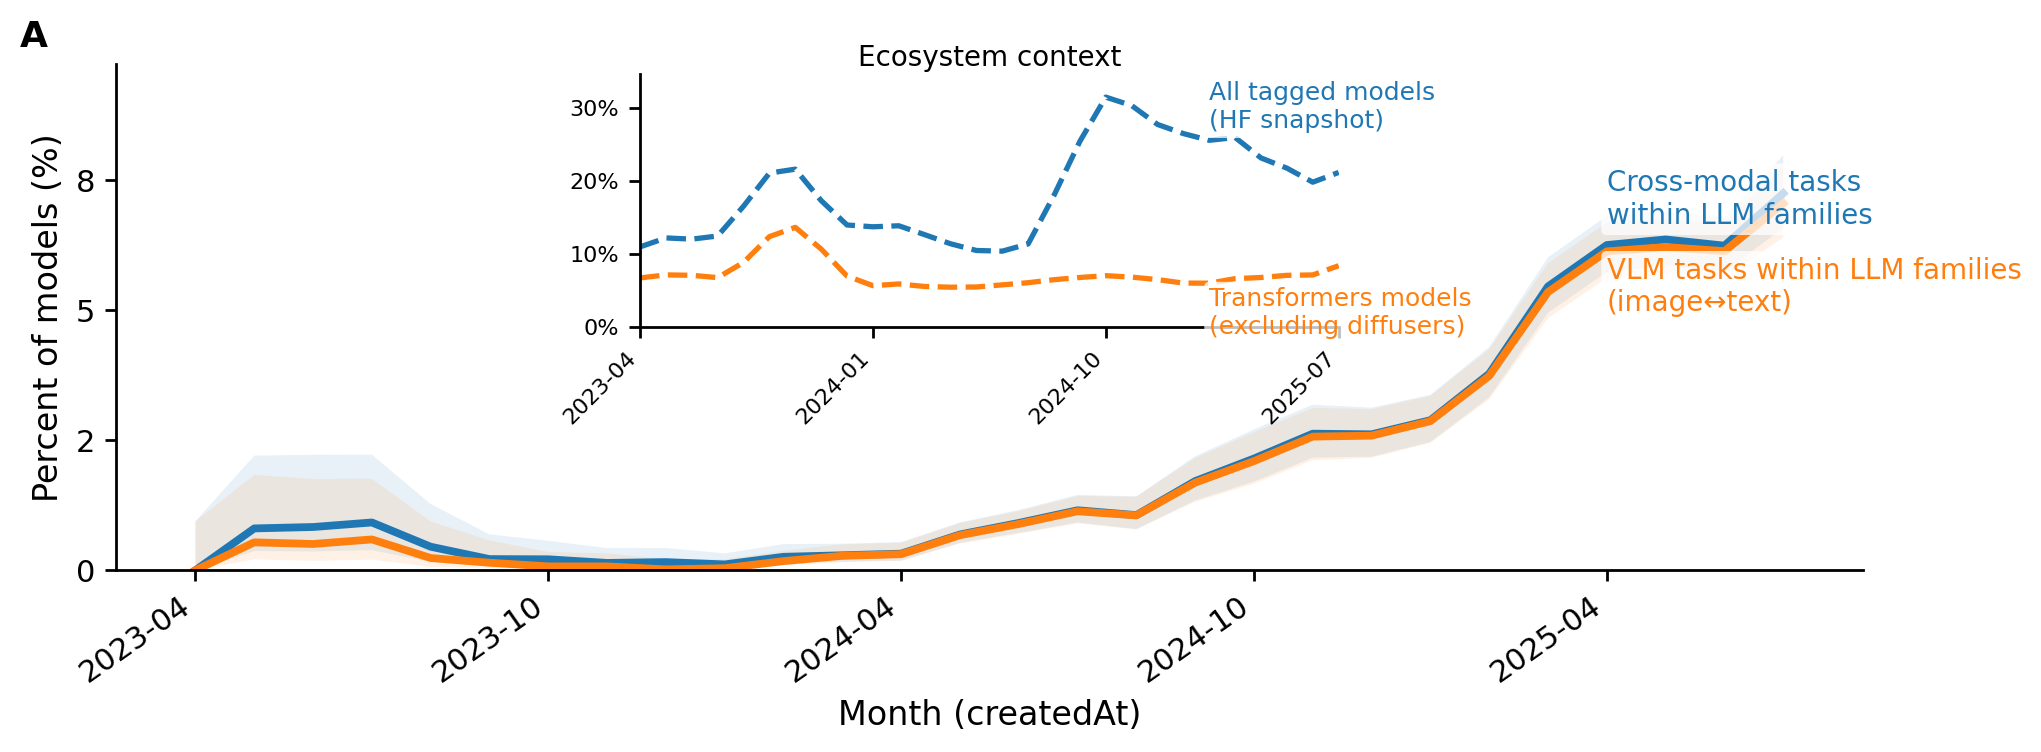

Saved: multimodality_trends_nature_centerinset.pdf and multimodality_trends_nature_centerinset.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# dfp_plot must contain shares (0–1):
# month,
# share_cm_all, share_cm_tf, share_cm_llm, share_vlm_llm,
# lo_cm_llm, hi_cm_llm, lo_vlm_llm, hi_vlm_llm

# -----------------------------
# 1) Prep: convert to percent
# -----------------------------
df = dfp_plot.copy()
to_pct = [
    "share_cm_all","share_cm_tf","share_cm_llm","share_vlm_llm",
    "lo_cm_llm","hi_cm_llm","lo_vlm_llm","hi_vlm_llm"
]
for c in to_pct:
    df[c] = df[c] * 100.0

x = np.arange(len(df))
labels = df["month"].tolist()

# -----------------------------
# 2) Style (Nature-ish)
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 700,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10.4, 3.9))

# -----------------------------
# 3) Main panel (LLM/VLM focus)
# -----------------------------
# Plot lines (keep handles to reuse colors)
l_cm, = ax.plot(x, df["share_cm_llm"], linewidth=2.8)
l_vlm, = ax.plot(x, df["share_vlm_llm"], linewidth=2.8)

# CI shading (subtle)
ax.fill_between(x, df["lo_cm_llm"], df["hi_cm_llm"], alpha=0.10, linewidth=0)
ax.fill_between(x, df["lo_vlm_llm"], df["hi_vlm_llm"], alpha=0.10, linewidth=0)

ax.set_xlabel("Month (createdAt)")
ax.set_ylabel("Percent of models (%)")
ax.grid(False)

# Zoom y to the story
ymax = np.nanmax([df["hi_cm_llm"].max(), df["hi_vlm_llm"].max()])
ax.set_ylim(0, max(6, ymax * 1.22))

# Cleaner ticks
ax.yaxis.set_major_locator(mtick.MaxNLocator(4))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))

# Fewer x ticks (every 6 months)
step = 6
xt = x[::step]
ax.set_xticks(xt)
ax.set_xticklabels([labels[i] for i in xt], rotation=35, ha="right")

# Panel label
ax.text(-0.055, 1.02, "A", transform=ax.transAxes, fontweight="bold",
        fontsize=13, va="bottom")

# ---- Direct labels INSIDE the plot (no right-edge collision) ----
# Find last non-nan y for both series
def last_valid(series):
    s = np.array(series, dtype=float)
    idx = np.where(~np.isnan(s))[0]
    return (idx[-1], s[idx[-1]]) if len(idx) else (len(s)-1, np.nan)

ix_cm, y_cm = last_valid(df["share_cm_llm"])
ix_v,  y_v  = last_valid(df["share_vlm_llm"])

# Put labels slightly before the end, inside the axes
x_text = min(ix_cm, len(x) - 1) - 3  # 3 points left from end
bbox_kw = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.75)

ax.text(x_text, df["share_cm_llm"].iloc[x_text] + 0.30,
        "Cross-modal tasks\nwithin LLM families",
        color=l_cm.get_color(), fontsize=10, va="bottom", ha="left", bbox=bbox_kw)

ax.text(x_text, df["share_vlm_llm"].iloc[x_text] - 0.10,
        "VLM tasks within LLM families\n(image↔text)",
        color=l_vlm.get_color(), fontsize=10, va="top", ha="left", bbox=bbox_kw)

# -----------------------------
# 4) Inset (top-center, context)
# -----------------------------
axins = inset_axes(
    ax, width="40%", height="52%", loc="upper center",
    bbox_to_anchor=(0.0, 0.02, 1.0, 0.96),
    bbox_transform=ax.transAxes, borderpad=0
)
axins.set_facecolor("white")

# Context lines (dashed)
c_all, = axins.plot(x, df["share_cm_all"], linewidth=1.9, linestyle="--")
c_tf,  = axins.plot(x, df["share_cm_tf"],  linewidth=1.9, linestyle="--")

axins.set_title("Ecosystem context", fontsize=10, pad=3)
axins.grid(False)

# Inset y scale: full context
ymax_in = np.nanmax([df["share_cm_all"].max(), df["share_cm_tf"].max()])
axins.set_ylim(0, ymax_in * 1.10)

# Inset ticks: very sparse
axins.set_xticks(x[::9])
axins.set_xticklabels([labels[i] for i in x[::9]], rotation=45, ha="right", fontsize=8)
axins.tick_params(axis="y", labelsize=8)
axins.yaxis.set_major_locator(mtick.MaxNLocator(4))
axins.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))

# Technical direct labels INSIDE inset near last points (avoid right spill)
x_in_text = len(x) - 6
axins.text(x_in_text, df["share_cm_all"].iloc[x_in_text] + 1.0,
           "All tagged models\n(HF snapshot)",
           color=c_all.get_color(), fontsize=9, ha="left", va="bottom", bbox=bbox_kw)

axins.text(x_in_text, df["share_cm_tf"].iloc[x_in_text] - 0.5,
           "Transformers models\n(excluding diffusers)",
           color=c_tf.get_color(), fontsize=9, ha="left", va="top", bbox=bbox_kw)

# Keep inset bounds tight (no extra x room needed now)
axins.set_xlim(x[0], x[-1])

# -----------------------------
# 5) Export
# -----------------------------
fig.tight_layout()
fig.savefig("multimodality_trends_nature_centerinset.pdf", bbox_inches="tight")
fig.savefig("multimodality_trends_nature_centerinset.png", bbox_inches="tight")
plt.show()

print("Saved: multimodality_trends_nature_centerinset.pdf and multimodality_trends_nature_centerinset.png")


Yep — these are exactly the “final 2%” tweaks. Here’s a drop-in replacement plotting cell that:

pushes the main labels away from the lines (bigger offsets + white halo box)

gives the inset neutral grayscale colors (so it doesn’t compete with the main blue/orange story)

moves the inset slightly left

keeps everything clean / Nature-y

Copy-paste this cell:

/tmp/ipython-input-3117102856.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


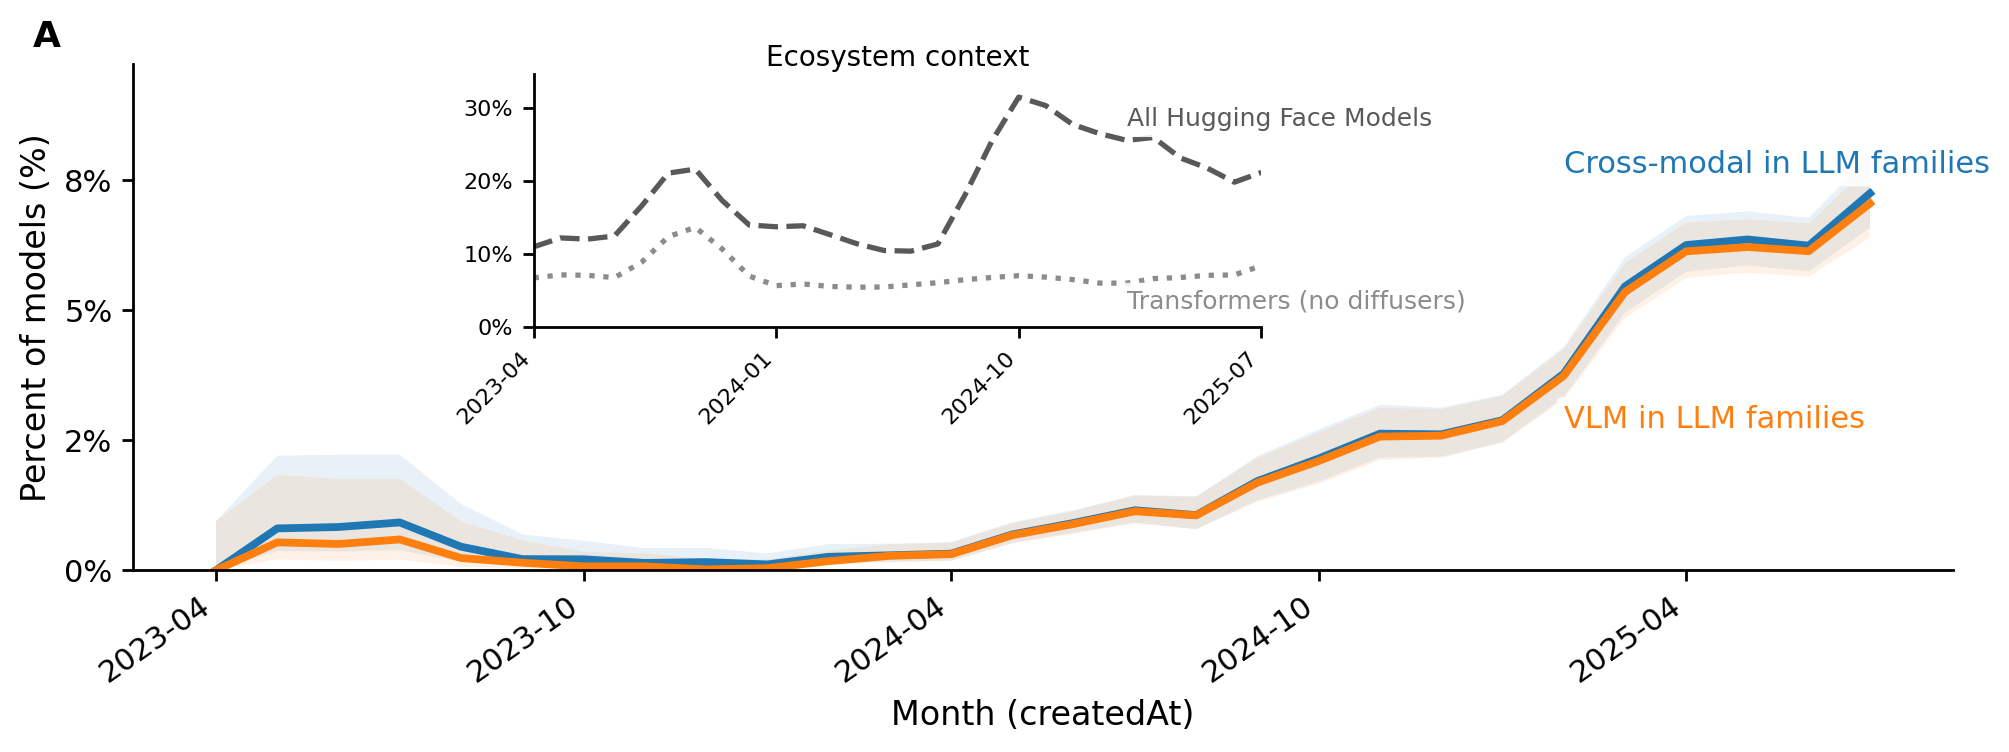

Saved: multimodality_trends_nature_final.pdf and multimodality_trends_nature_final.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# dfp_plot columns (shares 0–1):
# month,
# share_cm_all, share_cm_tf, share_cm_llm, share_vlm_llm,
# lo_cm_llm, hi_cm_llm, lo_vlm_llm, hi_vlm_llm

# -----------------------------
# 1) Prep: convert to percent
# -----------------------------
df = dfp_plot.copy()
for c in ["share_cm_all","share_cm_tf","share_cm_llm","share_vlm_llm",
          "lo_cm_llm","hi_cm_llm","lo_vlm_llm","hi_vlm_llm"]:
    df[c] = df[c] * 100.0

x = np.arange(len(df))
labels = df["month"].tolist()

# -----------------------------
# 2) Styling
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 700,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10.4, 3.9))

# -----------------------------
# 3) Main panel (LLM/VLM focus)
# -----------------------------
l_cm, = ax.plot(x, df["share_cm_llm"], linewidth=2.8)
l_vlm, = ax.plot(x, df["share_vlm_llm"], linewidth=2.8)

# CI shading (subtle)
ax.fill_between(x, df["lo_cm_llm"], df["hi_cm_llm"], alpha=0.10, linewidth=0)
ax.fill_between(x, df["lo_vlm_llm"], df["hi_vlm_llm"], alpha=0.10, linewidth=0)

ax.set_xlabel("Month (createdAt)")
ax.set_ylabel("Percent of models (%)")
ax.grid(False)

# y scale (zoom on story)
ymax = np.nanmax([df["hi_cm_llm"].max(), df["hi_vlm_llm"].max()])
ax.set_ylim(0, max(6, ymax * 1.22))
ax.yaxis.set_major_locator(mtick.MaxNLocator(4))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))

# x ticks (every 6 months)
step = 6
xt = x[::step]
ax.set_xticks(xt)
ax.set_xticklabels([labels[i] for i in xt], rotation=35, ha="right")

# panel label
ax.text(-0.055, 1.02, "A", transform=ax.transAxes, fontweight="bold",
        fontsize=13, va="bottom")

# ---- Main direct labels: more offset + white halo box ----
bbox_kw = dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.85)

# Place labels inside, not at the boundary
x_text = len(x) - 6  # a bit left from the end

# stronger vertical separation to avoid “blurring”
ax.text(x_text, df["share_cm_llm"].iloc[x_text] + 3.75,
        "Cross-modal in LLM families",
        color=l_cm.get_color(), fontsize=11, va="bottom", ha="left", bbox=bbox_kw)

ax.text(x_text, df["share_vlm_llm"].iloc[x_text] - 0.55,
        "VLM in LLM families",
        color=l_vlm.get_color(), fontsize=11, va="top", ha="left", bbox=bbox_kw)

# -----------------------------
# 4) Inset: ecosystem context (neutral grayscale), moved left
# -----------------------------
axins = inset_axes(
    ax, width="40%", height="52%", loc="upper center",
    # shift left by using a bbox anchored slightly left of center
    bbox_to_anchor=(-0.08, 0.02, 1.0, 0.96),
    bbox_transform=ax.transAxes, borderpad=0
)
axins.set_facecolor("white")

# grayscale context so it doesn't compete with main story
# (and still distinguishable with dashed vs dotted)
ctx_all, = axins.plot(x, df["share_cm_all"], linewidth=1.9,
                      linestyle="--", color="0.35")   # dark gray
ctx_tf,  = axins.plot(x, df["share_cm_tf"],  linewidth=1.9,
                      linestyle=":",  color="0.55")   # lighter gray

axins.set_title("Ecosystem context", fontsize=10, pad=3)
axins.grid(False)

ymax_in = np.nanmax([df["share_cm_all"].max(), df["share_cm_tf"].max()])
axins.set_ylim(0, ymax_in * 1.10)

# inset ticks: sparse
axins.set_xticks(x[::9])
axins.set_xticklabels([labels[i] for i in x[::9]], rotation=45, ha="right", fontsize=8)
axins.tick_params(axis="y", labelsize=8)
axins.yaxis.set_major_locator(mtick.MaxNLocator(4))
axins.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))

# inset direct labels (also with halo)
x_in_text = len(x) - 6
axins.text(x_in_text, df["share_cm_all"].iloc[x_in_text] + 1.3,
           "All Hugging Face Models", color="0.35",
           fontsize=9, va="bottom", ha="left", bbox=bbox_kw)

axins.text(x_in_text, df["share_cm_tf"].iloc[x_in_text] - 0.8,
           "Transformers (no diffusers)", color="0.55",
           fontsize=9, va="top", ha="left", bbox=bbox_kw)

axins.set_xlim(x[0], x[-1])

# -----------------------------
# 5) Export
# -----------------------------
fig.tight_layout()
fig.savefig("multimodality_trends_nature_final.pdf", bbox_inches="tight")
fig.savefig("multimodality_trends_nature_final.png", bbox_inches="tight")
plt.show()

print("Saved: multimodality_trends_nature_final.pdf and multimodality_trends_nature_final.png")


# One-sentence punchline (main text)

# Multimodality appears early in the open Hugging Face ecosystem, but it reaches LLM families later: while cross-modal tasks become common among all tagged models (and, to a lesser extent, among transformer models excluding diffusers), the share of LLM-family models assigned to cross-modal tasks stays near zero through 2023 and most of 2024 before rising sharply in 2024–2025. This late acceleration is driven primarily by vision–language models—the VLM (image↔text) curve tracks the broader cross-modal curve closely—suggesting that the current “multimodal turn” in open LLM lineages is largely a VLM turn rather than (so far) audio or video. Overall, the figure supports a diffusion-like pattern: multimodality establishes itself in the broader ecosystem first, then propagates into LLM-family development with a clear lag and rapid catch-up.

Figure 1 | Emergence of multimodality in LLM families on Hugging Face. Monthly percentage of newly created models in LLM families assigned to cross-modal tasks (text↔image/audio/video) and, within that, vision–language tasks (image↔text); inset shows ecosystem-wide context for all tagged models and transformers models excluding diffusers. LLM families are identified by a name-based proxy (LLM-family model_id patterns within transformers, excluding diffusers) and plotted only for months with sufficient volume (n≥300). Shaded bands denote 95% binomial confidence intervals (Wilson score) for monthly proportions using the dataset’s July 2025 snapshot.

Next step is the lineage / transition analysis: show how multimodality “enters” LLM families via parent→child relationships, not just that it increases over time.

Concretely:

Extract parent links from the dataset (finetune_parent, merge_parent, adapter_parent, quantized_parent).

Build a parent→child map (at least for a big sample) so you can assign each child a parent task label.

Estimate transition rates like:

𝑃
(
child is VLM
∣
parent is text-only LLM
)
P(child is VLM∣parent is text-only LLM)

𝑃
(
child is cross-modal
∣
parent is LLM
)
P(child is cross-modal∣parent is LLM)

Compare pathways:

fine-tunes vs merges vs adapters vs quantization

which parent families are “sources” of VLM descendants

Add one “emergence” figure: a transition matrix or a hazard curve over time (when the first VLM descendants appear and how that rate grows).

If you want, paste one row where any of the *_parent fields is non-empty, and I’ll give you the exact Colab code to build the parent→child transitions efficiently with streaming.

I can’t run your Colab for you from here, but you can make Colab find a non-empty *_parent row in ~1 minute with this exact cell.

Cell: find the first row with any non-empty parent field (with progress bar)

You just need to (re)define has_any_parent in the same runtime before that loop. In Colab, if you ran cells out of order (or restarted), functions disappear.

Here’s a single cell that includes everything (helpers + progress bar + collect 10 examples). Run this as-is:

In [ ]:
from datasets import load_dataset
from tqdm.auto import tqdm
import ast

DATASET = "modelbiome/ai_ecosystem_withmodelcards"

# If you already defined USECOLS earlier, keep it; otherwise just omit usecols for now.
# USECOLS = [...]

def parse_listish(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s == "[]":
            return []
        try:
            v = ast.literal_eval(s)
            return v if isinstance(v, list) else [v]
        except Exception:
            return []
    return []

PARENT_FIELDS = ["finetune_parent", "merge_parent", "adapter_parent", "quantized_parent"]

def has_any_parent(row):
    return any(len(parse_listish(row.get(f))) > 0 for f in PARENT_FIELDS)

# reload stream (important if ds was exhausted)
try:
    ds = load_dataset(DATASET, split="train", streaming=True, usecols=USECOLS)
except NameError:
    ds = load_dataset(DATASET, split="train", streaming=True)

examples = []
for row in tqdm(ds, desc="Collecting parent examples", unit="rows"):
    if has_any_parent(row):
        examples.append({
            "model_id": row.get("model_id"),
            "pipeline_tag": row.get("pipeline_tag"),
            "library_name": row.get("library_name"),
            "finetune_parent": parse_listish(row.get("finetune_parent")),
            "merge_parent": parse_listish(row.get("merge_parent")),
            "adapter_parent": parse_listish(row.get("adapter_parent")),
            "quantized_parent": parse_listish(row.get("quantized_parent")),
        })
    if len(examples) >= 10:
        break

examples


[{'model_id': 'THUDM/GLM-4.1V-9B-Thinking',
  'pipeline_tag': 'image-text-to-text',
  'library_name': 'transformers',
  'finetune_parent': ['THUDM/GLM-4-9B-0414'],
  'merge_parent': [],
  'adapter_parent': [],
  'quantized_parent': []},
 {'model_id': 'mistralai/Devstral-Small-2507',
  'pipeline_tag': 'text-generation',
  'library_name': 'vllm',
  'finetune_parent': ['mistralai/Mistral-Small-3.1-24B-Instruct-2503'],
  'merge_parent': [],
  'adapter_parent': [],
  'quantized_parent': []},
 {'model_id': 'apple/DiffuCoder-7B-cpGRPO',
  'pipeline_tag': None,
  'library_name': None,
  'finetune_parent': ['apple/DiffuCoder-7B-Instruct'],
  'merge_parent': [],
  'adapter_parent': [],
  'quantized_parent': []},
 {'model_id': 'ChatDOC/OCRFlux-3B',
  'pipeline_tag': 'image-to-text',
  'library_name': 'transformers',
  'finetune_parent': ['Qwen/Qwen2.5-VL-3B-Instruct'],
  'merge_parent': [],
  'adapter_parent': [],
  'quantized_parent': []},
 {'model_id': 'google/gemma-3n-E4B-it',
  'pipeline_tag'

Awesome — those examples confirm the dataset has exactly what we need (finetune_parent, quantized_parent, etc.). Next step is:

Build parent→child edges, look up the parent’s pipeline_tag, and count “transitions” (e.g., text-generation → image-text-to-text) by relation type (finetune vs quantize vs merge vs adapter). This gives you Figure 2.

Below is a streaming-friendly, two-pass Colab recipe (with progress bars).

Cell 1 — edge extraction helpers

In [ ]:
from collections import Counter, defaultdict
from tqdm.auto import tqdm
import pandas as pd

PARENT_FIELDS = {
    "finetune": "finetune_parent",
    "merge": "merge_parent",
    "adapter": "adapter_parent",
    "quantized": "quantized_parent",
}

VLM_TASKS = {"image-to-text", "image-text-to-text"}
CROSS_MODAL = {
    "text-to-image",
    "image-to-text",
    "image-text-to-text",
    "automatic-speech-recognition",
    "text-to-speech",
    "text-to-video",
    "audio-to-audio",
    "any-to-any",
}

def iter_edges(row):
    """Yield (relation, parent_id, child_id, child_task, child_createdAt)"""
    child = row.get("model_id")
    child_task = row.get("pipeline_tag")
    child_created = row.get("createdAt")
    for rel, field in PARENT_FIELDS.items():
        for parent in parse_listish(row.get(field)):
            if parent:
                yield (rel, parent, child, child_task, child_created)


Cell 2 — Pass A: collect edges of interest + the set of parent IDs to resolve

Here we’ll focus on children that are in your LLM-family proxy (same definition you used for Fig 1). If you want all children, remove that if.

In [ ]:
# IMPORTANT: reload the stream each pass
ds = load_dataset(DATASET, split="train", streaming=True, usecols=USECOLS)

edges = []                 # store sampled edges (can be large; we’ll cap)
need_parents = set()

MAX_EDGES = 2_000_000       # safety cap; adjust up/down
for row in tqdm(ds, desc="Pass A: collecting edges", unit="rows"):
    # keep consistent with Fig 1 (optional):
    if not is_llm_family(row):
        continue

    for rel, parent, child, child_task, child_created in iter_edges(row):
        # ignore children with unknown task
        if child_task is None:
            continue

        edges.append((rel, parent, child, child_task, child_created))
        need_parents.add(parent)

    if len(edges) >= MAX_EDGES:
        break

print("Edges collected:", len(edges))
print("Unique parents to resolve:", len(need_parents))
edges[:3]


Pass A: collecting edges: 0rows [00:00, ?rows/s]

Edges collected: 50744
Unique parents to resolve: 8035


[('finetune',
  'google/gemma-3n-E4B',
  'google/gemma-3n-E4B-it',
  'image-text-to-text',
  '2025-06-03T18:17:07.000Z'),
 ('quantized',
  'deepseek-ai/DeepSeek-R1',
  'tngtech/DeepSeek-TNG-R1T2-Chimera',
  'text-generation',
  '2025-07-02T12:05:00.000Z'),
 ('finetune',
  'google/gemma-3-27b-pt',
  'google/medgemma-27b-it',
  'image-text-to-text',
  '2025-07-09T17:00:00.000Z')]

Cell 3 — Pass B: build a mapping parent_id → parent pipeline_tag (only for needed parents)

In [ ]:
ds = load_dataset(DATASET, split="train", streaming=True, usecols=USECOLS)

parent_task = {}
parent_created = {}
parent_lib = {}

for row in tqdm(ds, desc="Pass B: resolving parent tasks", unit="rows"):
    mid = row.get("model_id")
    if mid in need_parents:
        parent_task[mid] = row.get("pipeline_tag")
        parent_created[mid] = row.get("createdAt")
        parent_lib[mid] = row.get("library_name")
        # stop early if we've found them all
        if len(parent_task) >= len(need_parents):
            break

print("Resolved parents:", len(parent_task), "out of", len(need_parents))


Pass B: resolving parent tasks: 0rows [00:00, ?rows/s]

Resolved parents: 7811 out of 8035


Cell 4 — Build the transition table (relation × parent_task × child_task)

In [ ]:
rows = []
unknown_parent = 0

for rel, parent, child, child_task, child_created in tqdm(edges, desc="Joining edges", unit="edges"):
    ptask = parent_task.get(parent)
    if ptask is None:
        unknown_parent += 1
        continue
    rows.append((rel, ptask, child_task))

trans_df = (
    pd.DataFrame(rows, columns=["relation", "parent_task", "child_task"])
      .value_counts()
      .reset_index(name="n_edges")
      .sort_values("n_edges", ascending=False)
)

print("Edges with unresolved parent task:", unknown_parent)
trans_df.head(25)


Joining edges:   0%|          | 0/50744 [00:00<?, ?edges/s]

Edges with unresolved parent task: 2722


,relation,parent_task,child_task,n_edges
0,finetune,text-generation,text-generation,22340
1,merge,text-generation,text-generation,11566
2,quantized,text-generation,text-generation,10420
3,quantized,image-text-to-text,image-text-to-text,635
4,finetune,image-text-to-text,image-text-to-text,484
5,finetune,image-text-to-text,image-to-text,456
6,finetune,image-text-to-text,text-generation,455
7,finetune,text-generation,text-classification,301
8,finetune,fill-mask,text-classification,135
9,adapter,text-generation,text-generation,90


Cell 5 — The “emergence” statistic you probably want

Example: Among finetunes from text-generation parents, what % of children are VLM?
(You can do the same for cross-modal, or for different parent tasks.)

In [ ]:
def share_child_in_set(df, relation, parent_task, child_set):
    sub = df[(df["relation"] == relation) & (df["parent_task"] == parent_task)]
    total = sub["n_edges"].sum()
    if total == 0:
        return 0.0, 0
    in_set = sub[sub["child_task"].isin(child_set)]["n_edges"].sum()
    return in_set / total, total

for rel in ["finetune", "merge", "adapter", "quantized"]:
    p, n = share_child_in_set(trans_df, rel, "text-generation", VLM_TASKS)
    print(f"{rel:9s}  P(child is VLM | parent=text-generation) = {p:.3%}   (n={n})")


finetune   P(child is VLM | parent=text-generation) = 0.218%   (n=22928)
merge      P(child is VLM | parent=text-generation) = 0.104%   (n=11594)
adapter    P(child is VLM | parent=text-generation) = 1.031%   (n=97)
quantized  P(child is VLM | parent=text-generation) = 0.133%   (n=10487)


In [ ]:
Cell 6 — “Nature-ish” heatmap for Figure 2 (optional but very effective)

Focus on the most common parent/child tasks so it’s readable.

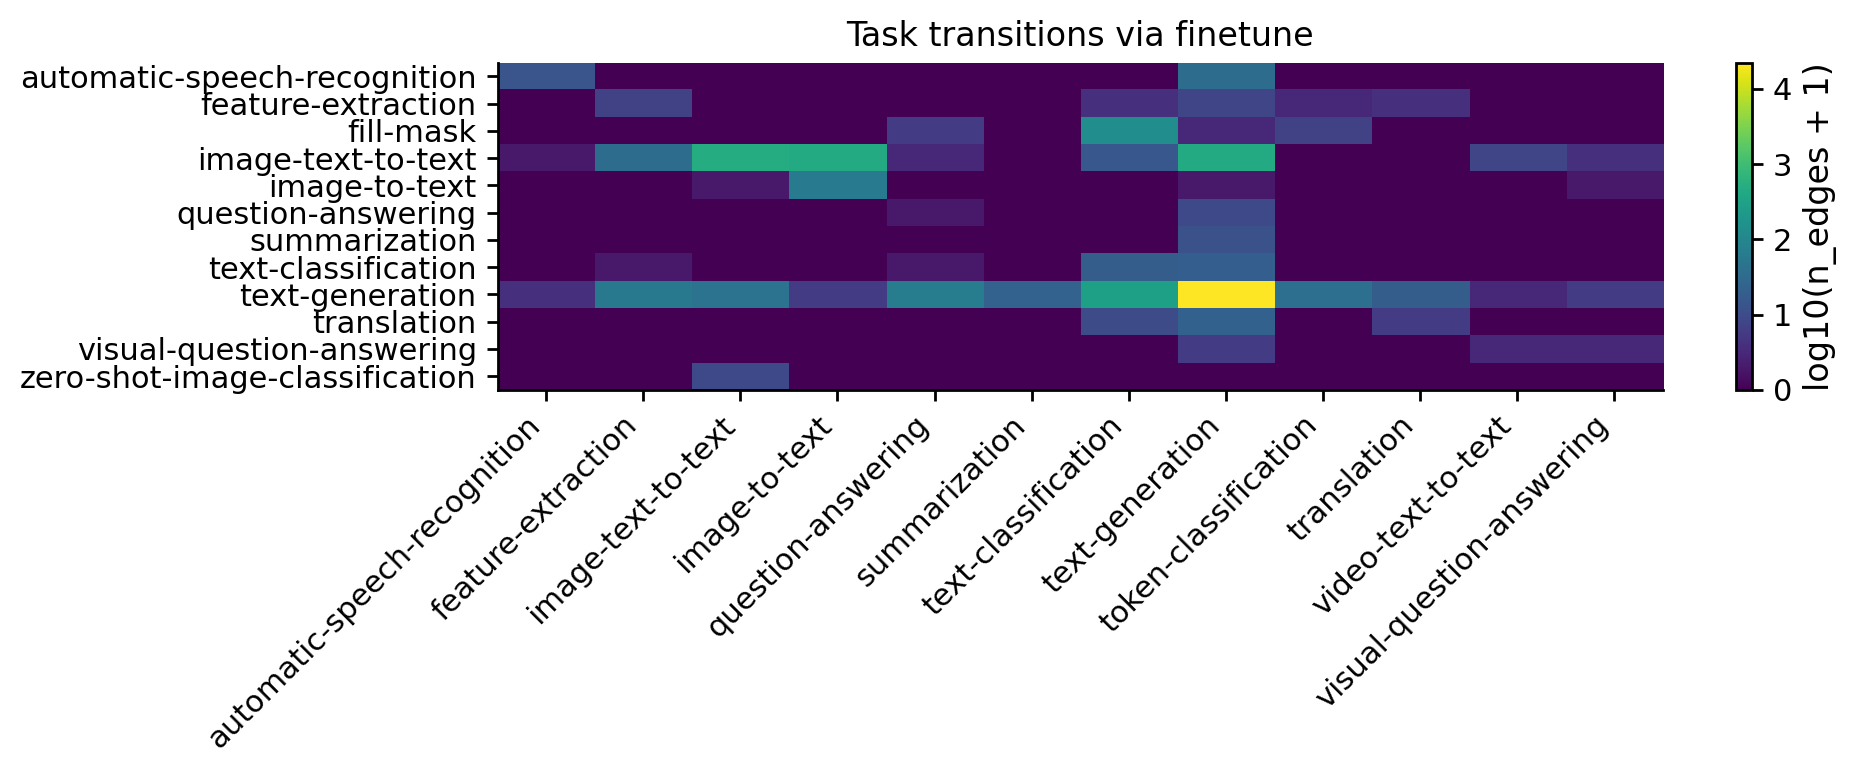

In [ ]:
import matplotlib.pyplot as plt

REL = "finetune"
TOPK = 12

sub = trans_df[trans_df["relation"] == REL].copy()

top_parents = sub.groupby("parent_task")["n_edges"].sum().sort_values(ascending=False).head(TOPK).index
top_children = sub.groupby("child_task")["n_edges"].sum().sort_values(ascending=False).head(TOPK).index

mat = (sub[sub["parent_task"].isin(top_parents) & sub["child_task"].isin(top_children)]
       .pivot_table(index="parent_task", columns="child_task", values="n_edges", aggfunc="sum", fill_value=0)
      )

# log scale makes heavy tails readable
mat_log = np.log10(mat + 1)

plt.figure(figsize=(10,4))
plt.imshow(mat_log.values, aspect="auto")
plt.yticks(range(len(mat_log.index)), mat_log.index)
plt.xticks(range(len(mat_log.columns)), mat_log.columns, rotation=45, ha="right")
plt.colorbar(label="log10(n_edges + 1)")
plt.title(f"Task transitions via {REL}")
plt.tight_layout()
plt.show()


Yep — this is very good, and the numbers you printed are exactly the kind of “mechanism” evidence that makes Fig. 1 feel real.

What Fig. 2 + those rates are saying

Fine-tunes overwhelmingly preserve task (the bright diagonal, especially text-generation → text-generation). That’s expected: most derivatives stay in the same pipeline tag.

There is a detectable pathway from text-generation parents into VLM children, but it’s rare per edge:

finetune: 0.218% of text-generation parent edges produce a VLM child (n=22,928) → ≈ 50 VLM children

merge: 0.104% (n=11,594) → ≈ 12

quantized: 0.133% (n=10,487) → ≈ 14

adapter: 1.031% (n=97) → ≈ 1 (so ignore the %; n is tiny)

So the clean story is: the per-edge “mutation” into VLM is low, but because there are so many finetunes, finetuning likely contributes the largest absolute number of VLM descendants.

This also explains Fig. 1’s lagged takeoff: you get a small mutation rate × huge volume → eventually a visible ecosystem-level rise.

What to add (so this is paper-solid)
A small table for Fig. 2 (worth it)

A 4-row table with k/n + 95% CI for the four relation types. Reviewers love this because it pins the heatmap down to one headline statistic.

One extra plot (optional but strong)

A time-resolved version of the transition rate:

𝑃
(
child is VLM
∣
parent=text-generation
,
relation=r
,
month
)
P(child is VLM∣parent=text-generation,relation=r,month)

That lets you show the “mutation rate” itself increases in 2024–2025, not just the stock of models.

Drop-in code: Table with k/n + Wilson 95% CI

Assumes you still have trans_df from your join step.

In [ ]:
import pandas as pd
import numpy as np
import math

VLM_TASKS = {"image-to-text", "image-text-to-text"}

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = (z * math.sqrt((p*(1-p) + z*z/(4*n)) / n)) / denom
    return (max(0.0, center-half), min(1.0, center+half))

def kn_for(df, relation, parent_task, child_set):
    sub = df[(df["relation"] == relation) & (df["parent_task"] == parent_task)]
    n = int(sub["n_edges"].sum())
    k = int(sub[sub["child_task"].isin(child_set)]["n_edges"].sum())
    return k, n

rows = []
for rel in ["finetune", "merge", "adapter", "quantized"]:
    k, n = kn_for(trans_df, rel, "text-generation", VLM_TASKS)
    lo, hi = wilson_ci(k, n)
    rows.append({
        "relation": rel,
        "k (VLM edges)": k,
        "n (all edges)": n,
        "rate (%)": 100 * (k/n) if n else np.nan,
        "95% CI (%)": f"{100*lo:.3f}–{100*hi:.3f}" if n else ""
    })

tab = pd.DataFrame(rows)
tab


,relation,k (VLM edges),n (all edges),rate (%),95% CI (%)
0,finetune,50,22928,0.218074,0.165–0.287
1,merge,12,11594,0.103502,0.059–0.181
2,adapter,1,97,1.030928,0.182–5.611
3,quantized,14,10487,0.133499,0.080–0.224


In [ ]:
tab.sort_values("rate (%)", ascending=False).to_markdown(index=False)


'| relation   |   k (VLM edges) |   n (all edges) |   rate (%) | 95% CI (%)   |\n|:-----------|----------------:|----------------:|-----------:|:-------------|\n| adapter    |               1 |              97 |   1.03093  | 0.182–5.611  |\n| finetune   |              50 |           22928 |   0.218074 | 0.165–0.287  |\n| quantized  |              14 |           10487 |   0.133499 | 0.080–0.224  |\n| merge      |              12 |           11594 |   0.103502 | 0.059–0.181  |'

Quick fix for the heatmap readability (if you keep it)

Right now the heatmap is informative, but it’s visually heavy. The simplest “Nature” tweak is to abbreviate task labels so the axis stops screaming.

Example mapping:

In [ ]:
ABBR = {
    "text-generation": "txt-gen",
    "image-text-to-text": "img+txt→txt",
    "image-to-text": "img→txt",
    "text-classification": "txt-cls",
    "token-classification": "tok-cls",
    "automatic-speech-recognition": "ASR",
    "text-to-speech": "TTS",
    "visual-question-answering": "VQA",
    "question-answering": "QA",
    "summarization": "summ",
    "translation": "trans",
    "feature-extraction": "feat",
    "fill-mask": "mask",
}


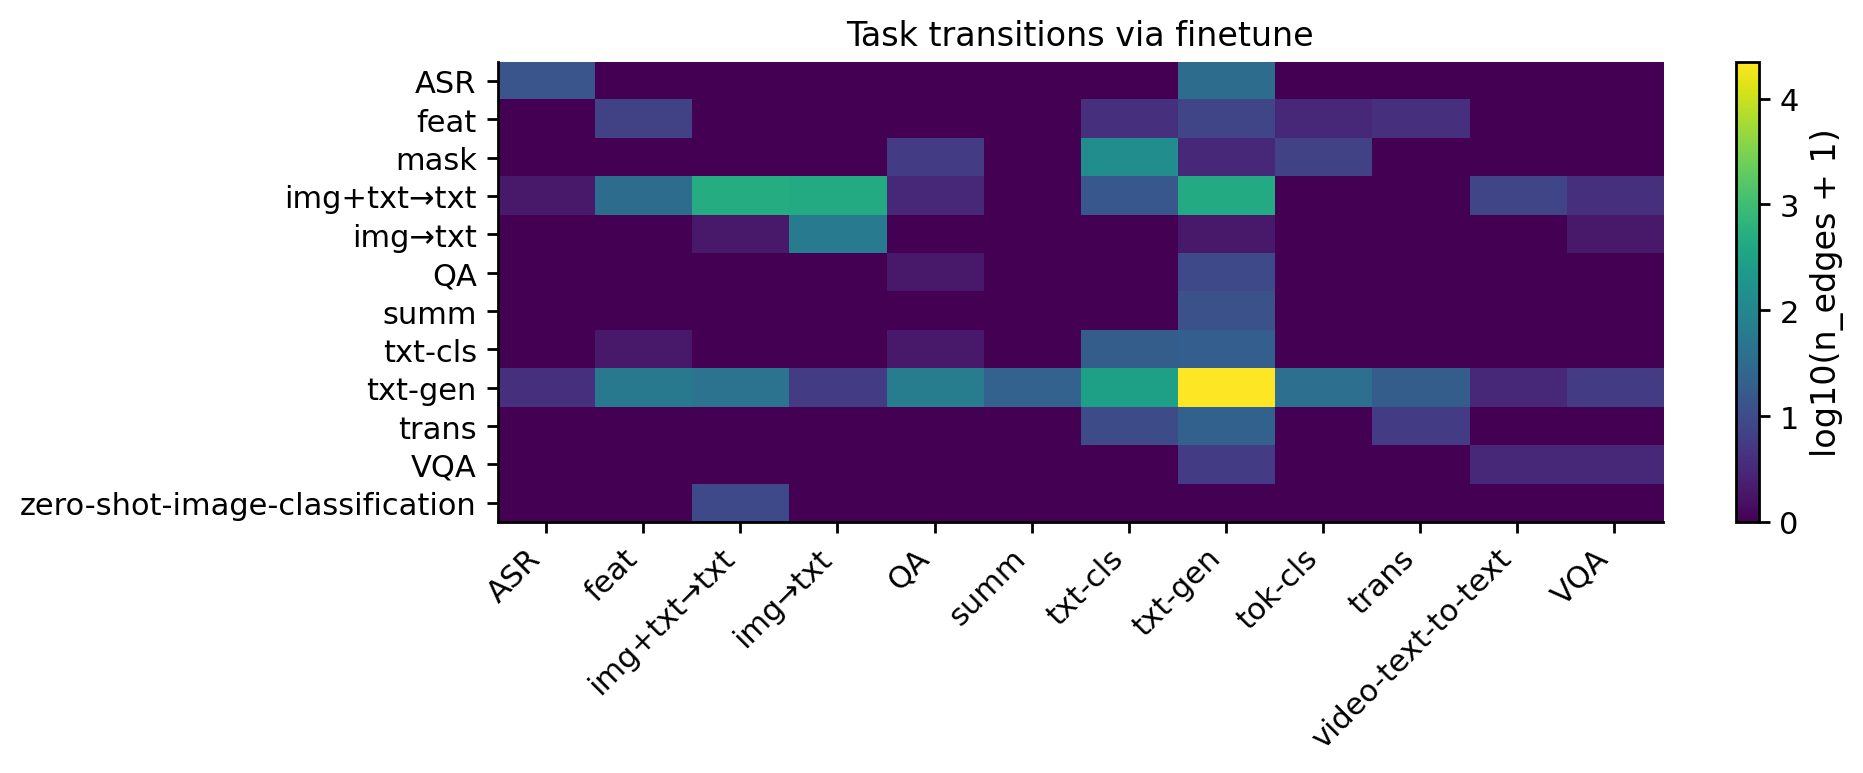

In [ ]:
import matplotlib.pyplot as plt

REL = "finetune"
TOPK = 12

sub = trans_df[trans_df["relation"] == REL].copy()

top_parents = sub.groupby("parent_task")["n_edges"].sum().sort_values(ascending=False).head(TOPK).index
top_children = sub.groupby("child_task")["n_edges"].sum().sort_values(ascending=False).head(TOPK).index

mat = (sub[sub["parent_task"].isin(top_parents) & sub["child_task"].isin(top_children)]
       .pivot_table(index="parent_task", columns="child_task", values="n_edges", aggfunc="sum", fill_value=0)
      )

# log scale makes heavy tails readable
mat_log = np.log10(mat + 1)

plt.figure(figsize=(10,4))
plt.imshow(mat_log.values, aspect="auto")
plt.yticks(range(len(mat_log.index)), [ABBR.get(x,x) for x in mat_log.index])
plt.xticks(range(len(mat_log.columns)), [ABBR.get(x,x) for x in mat_log.columns], rotation=45, ha="right")
plt.colorbar(label="log10(n_edges + 1)")
plt.title(f"Task transitions via {REL}")
plt.tight_layout()
plt.show()

This is excellent — with this heatmap + that small table, you now have a very defensible Fig. 2 package.

What you can confidently say (and should say)

Most fine-tunes are task-preserving (strong diagonal; especially txt-gen → txt-gen).

VLM emergence from text-generation parents exists but is rare per edge:

finetune: 0.218% (50/22,928; 95% CI 0.165–0.287)

merge: 0.104% (12/11,594; 0.059–0.181)

quantized: 0.133% (14/10,487; 0.080–0.224)

adapter: 1/97 (too small-n to interpret; wide CI)

So: finetuning is the dominant pathway in absolute counts (50 VLM edges), even if the “mutation rate” is low.

That pairs perfectly with Fig. 1’s “late takeoff”: a low conversion rate × huge volume = noticeable growth only later.

Two small improvements (optional, but worth it)
1) Rename the table metric to be precise

Right now it reads like “VLM emerges from text-generation parents via finetune”. Make it explicit that this is edge-level and uses your VLM definition:

“VLM child” = pipeline_tag ∈ {image-to-text, image-text-to-text}

2) Add one extra row: “cross-modal (any)” not just VLM

This shows whether multimodal emergence is specifically VLM or broader.

If you run:

In [ ]:
CROSS_MODAL = {
    "text-to-image","image-to-text","image-text-to-text",
    "automatic-speech-recognition","text-to-speech","text-to-video",
    "audio-to-audio","any-to-any"
}

In [ ]:
import pandas as pd
import numpy as np
import math

# --- define task sets ---
VLM_TASKS = {"image-to-text", "image-text-to-text"}

CROSS_MODAL = {
    "text-to-image","image-to-text","image-text-to-text",
    "automatic-speech-recognition","text-to-speech","text-to-video",
    "audio-to-audio","any-to-any"
}

# --- Wilson CI helper (same as before) ---
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = (z * math.sqrt((p*(1-p) + z*z/(4*n)) / n)) / denom
    return (max(0.0, center-half), min(1.0, center+half))

# --- k/n extractor from trans_df ---
def kn_for(df, relation, parent_task, child_set):
    sub = df[(df["relation"] == relation) & (df["parent_task"] == parent_task)]
    n = int(sub["n_edges"].sum())
    k = int(sub[sub["child_task"].isin(child_set)]["n_edges"].sum())
    return k, n

rows = []
for rel in ["finetune", "merge", "adapter", "quantized"]:
    # Cross-modal (any)
    k, n = kn_for(trans_df, rel, "text-generation", CROSS_MODAL)
    lo, hi = wilson_ci(k, n)
    rows.append({
        "relation": rel,
        "metric": "P(cross-modal child | parent=text-generation)",
        "k": k,
        "n": n,
        "rate (%)": 100*(k/n) if n else np.nan,
        "95% CI (%)": f"{100*lo:.3f}–{100*hi:.3f}" if n else ""
    })

    # VLM (subset)
    k, n = kn_for(trans_df, rel, "text-generation", VLM_TASKS)
    lo, hi = wilson_ci(k, n)
    rows.append({
        "relation": rel,
        "metric": "P(VLM child | parent=text-generation)",
        "k": k,
        "n": n,
        "rate (%)": 100*(k/n) if n else np.nan,
        "95% CI (%)": f"{100*lo:.3f}–{100*hi:.3f}" if n else ""
    })

tab2 = pd.DataFrame(rows)

# Optional: also compute "VLM as a fraction of cross-modal" for each relation
vlm_frac = []
for rel in ["finetune", "merge", "adapter", "quantized"]:
    k_cm, n_cm = kn_for(trans_df, rel, "text-generation", CROSS_MODAL)
    k_vlm, _   = kn_for(trans_df, rel, "text-generation", VLM_TASKS)
    frac = (k_vlm / k_cm) if k_cm else np.nan
    vlm_frac.append({"relation": rel, "VLM / cross-modal (%)": 100*frac if frac==frac else np.nan, "cross-modal k": k_cm})

vlm_frac = pd.DataFrame(vlm_frac)

tab2, vlm_frac


(    relation                                         metric   k      n  \
 0   finetune  P(cross-modal child | parent=text-generation)  54  22928   
 1   finetune          P(VLM child | parent=text-generation)  50  22928   
 2      merge  P(cross-modal child | parent=text-generation)  12  11594   
 3      merge          P(VLM child | parent=text-generation)  12  11594   
 4    adapter  P(cross-modal child | parent=text-generation)   1     97   
 5    adapter          P(VLM child | parent=text-generation)   1     97   
 6  quantized  P(cross-modal child | parent=text-generation)  14  10487   
 7  quantized          P(VLM child | parent=text-generation)  14  10487   
 
    rate (%)   95% CI (%)  
 0  0.235520  0.181–0.307  
 1  0.218074  0.165–0.287  
 2  0.103502  0.059–0.181  
 3  0.103502  0.059–0.181  
 4  1.030928  0.182–5.611  
 5  1.030928  0.182–5.611  
 6  0.133499  0.080–0.224  
 7  0.133499  0.080–0.224  ,
     relation  VLM / cross-modal (%)  cross-modal k
 0   finetune     

Nice — this is a very crisp result.

What your new numbers mean (in plain technical terms)

For descendants of text-generation parents:

Cross-modal emergence is rare overall (fine-tune: 0.236%, 54/22,928 edges).

But when cross-modal emergence happens, it is almost entirely VLM:

finetune: 92.6% of cross-modal edges are VLM (50/54)

merge / quantized: 100% VLM (12/12, 14/14) — but note these are small counts

adapter: 1/1 (n is tiny)

So you can say: “cross-modal ≈ VLM” for these lineage transitions; i.e., the multimodal pathway you’re seeing is basically the image↔text pathway, not audio/video.

One sentence you can drop into Results

Across parent→child edges from text-generation parents, cross-modal descendants are rare (≤0.24% of edges), and overwhelmingly VLM: 50 of 54 (92.6%) cross-modal finetune transitions are VLM, and all observed cross-modal transitions via merges and quantization are VLM (12/12 and 14/14 edges, respectively).

(Recommended) identify the 4 “non-VLM cross-modal” finetune children

This makes the story even tighter (“the remaining 4 are …”).

In [ ]:
NON_VLM_CM = CROSS_MODAL - VLM_TASKS

(trans_df[
    (trans_df["relation"]=="finetune") &
    (trans_df["parent_task"]=="text-generation") &
    (trans_df["child_task"].isin(NON_VLM_CM))
]
 .sort_values("n_edges", ascending=False)
)


,relation,parent_task,child_task,n_edges
93,finetune,text-generation,automatic-speech-recognition,3
140,finetune,text-generation,audio-to-audio,1


What I’d do next (if you want a third result, but still “quick paper”)

Make the transition rate time-resolved (one line plot):

y:
𝑃
(
child is VLM
∣
parent=text-generation
,
relation=finetune
)
P(child is VLM∣parent=text-generation,relation=finetune)

x: month of child creation

If that rate rises in late 2024–2025, it becomes a really strong mechanistic explanation for Fig. 1.

If you want, I’ll give you the exact streaming-friendly code to compute that monthly conditional rate (it’s basically the same join, but binned by child_createdAt[:7]).

Below is streaming-friendly, 3-pass Colab code to compute and plot the time-resolved “VLM mutation rate”:

𝑃
(
child is VLM
∣
parent task = text-generation
,
relation = finetune
)
P(child is VLM∣parent task = text-generation,relation = finetune)

binned by child month (createdAt[:7]).

It avoids storing all edges in memory.

In [ ]:
Cell 0 — prerequisites (assumes you already have helpers)

This assumes you already defined:

DATASET, USECOLS

parse_listish(x) and parse_month(createdAt)

is_llm_family(row) (your Fig 1 proxy)

If not, tell me and I’ll paste a self-contained version.

In [ ]:
from datasets import load_dataset
from tqdm.auto import tqdm
from collections import Counter
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

VLM_TASKS = {"image-to-text", "image-text-to-text"}
REL_FIELD = "finetune_parent"

# Match Fig 1: ignore months before CreatedAt is reliable (optional)
CUTOFF_MONTH = "2022-03"

# Optional: restrict to the same population as Fig 1 (LLM families)
RESTRICT_TO_LLM_CHILDREN = True


In [ ]:
Cell 1 — Pass A: collect finetune parent IDs we need to resolve

In [ ]:
ds = load_dataset(DATASET, split="train", streaming=True, usecols=USECOLS)

need_parents = set()

for row in tqdm(ds, desc="Pass A: collecting finetune parents", unit="rows"):
    if RESTRICT_TO_LLM_CHILDREN and (not is_llm_family(row)):
        continue

    parents = parse_listish(row.get(REL_FIELD))
    for p in parents:
        if p:
            need_parents.add(p)

print("Unique finetune parents to resolve:", len(need_parents))


Pass A: collecting finetune parents: 0rows [00:00, ?rows/s]

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: baacbafc-038f-4608-8c75-c36796a58ebd)')' thrown while requesting GET https://huggingface.co/datasets/modelbiome/ai_ecosystem_withmodelcards/resolve/4cb5d8739a8fce7c03826994dd756c244b4126bf/ai_ecosystem_withmodelcards.csv
Retrying in 1s [Retry 1/5].


Unique finetune parents to resolve: 3409


Cell 2 — Pass B: map parent_id → parent_task (pipeline_tag)

In [ ]:
ds = load_dataset(DATASET, split="train", streaming=True, usecols=USECOLS)

parent_task = {}

for row in tqdm(ds, desc="Pass B: resolving parent tasks", unit="rows"):
    mid = row.get("model_id")
    if mid in need_parents:
        parent_task[mid] = row.get("pipeline_tag")
        if len(parent_task) >= len(need_parents):
            break

print("Resolved parent tasks:", len(parent_task), "out of", len(need_parents))


Pass B: resolving parent tasks: 0rows [00:00, ?rows/s]

Resolved parent tasks: 3289 out of 3409


Cell 3 — Pass C: compute monthly numerator/denominator (streaming)

Denominator = count of finetune edges where parent_task == 'text-generation'
Numerator = those edges whose child is VLM (image-to-text or image-text-to-text)

In [ ]:
ds = load_dataset(DATASET, split="train", streaming=True, usecols=USECOLS)

den = Counter()   # per month
num = Counter()   # per month
unresolved = 0

for row in tqdm(ds, desc="Pass C: counting monthly finetune transitions", unit="rows"):
    if RESTRICT_TO_LLM_CHILDREN and (not is_llm_family(row)):
        continue

    month = parse_month(row.get("createdAt"))
    if (not month) or (month < CUTOFF_MONTH):
        continue

    child_task = row.get("pipeline_tag")
    if child_task is None:
        continue

    parents = parse_listish(row.get(REL_FIELD))
    if not parents:
        continue

    for p in parents:
        ptask = parent_task.get(p)
        if ptask is None:
            unresolved += 1
            continue

        if ptask == "text-generation":
            den[month] += 1
            if child_task in VLM_TASKS:
                num[month] += 1

print("Unresolved parent-task lookups (edges):", unresolved)
print("Total denominator edges:", sum(den.values()))
print("Total numerator edges:", sum(num.values()))


Pass C: counting monthly finetune transitions: 0rows [00:00, ?rows/s]

Unresolved parent-task lookups (edges): 802
Total denominator edges: 22928
Total numerator edges: 50


Cell 4 — Build dataframe + Wilson 95% CI

In [ ]:
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = (z * math.sqrt((p*(1-p) + z*z/(4*n)) / n)) / denom
    return (max(0.0, center-half), min(1.0, center+half))

months = sorted(den.keys())

df_rate = pd.DataFrame({
    "month": months,
    "k_vlm": [num[m] for m in months],
    "n_edges": [den[m] for m in months],
})
df_rate["rate"] = df_rate["k_vlm"] / df_rate["n_edges"]

cis = [wilson_ci(k, n) for k, n in zip(df_rate["k_vlm"], df_rate["n_edges"])]
df_rate["ci_lo"] = [c[0] for c in cis]
df_rate["ci_hi"] = [c[1] for c in cis]

df_rate.tail(12)


,month,k_vlm,n_edges,rate,ci_lo,ci_hi
17,2024-08,2,453,0.004415,0.001212,0.015953
18,2024-09,5,765,0.006536,0.002795,0.015208
19,2024-10,2,697,0.002869,0.000787,0.010402
20,2024-11,10,1061,0.009425,0.005127,0.017262
21,2024-12,5,1289,0.003879,0.001658,0.009048
22,2025-01,4,1510,0.002649,0.001031,0.006792
23,2025-02,3,1661,0.001806,0.000614,0.005297
24,2025-03,6,2249,0.002668,0.001223,0.005809
25,2025-04,1,4091,0.000244,0.000043,0.001383
26,2025-05,3,2265,0.001325,0.000451,0.003887


Cell 5 — Plot (publication-clean, percent axis)

This is the “third result” figure.

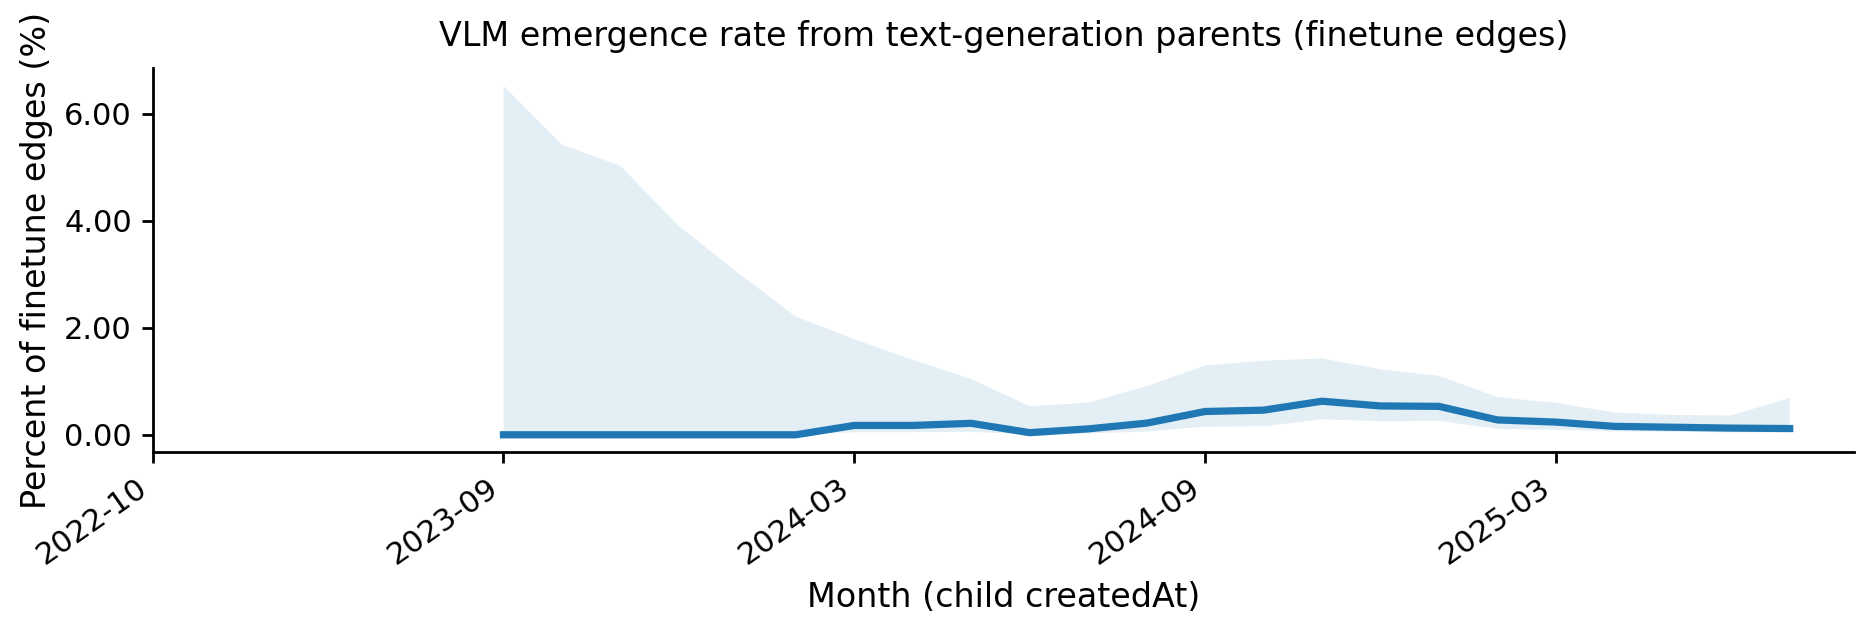

Saved: vlm_transition_rate_over_time.pdf and .png


In [ ]:
# Optional: drop months with tiny denominators (reduces noise)
MIN_EDGES_PER_MONTH = 50
dfp = df_rate.copy()
dfp.loc[dfp["n_edges"] < MIN_EDGES_PER_MONTH, ["rate","ci_lo","ci_hi"]] = np.nan

# Optional smoothing (comment out if you want raw)
SMOOTH = 3
for c in ["rate","ci_lo","ci_hi"]:
    dfp[c] = dfp[c].rolling(SMOOTH, min_periods=1).mean()

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(9.5, 3.3))

# Convert to percent for display
ax.plot(dfp["month"], 100*dfp["rate"], linewidth=2.6)
ax.fill_between(dfp["month"], 100*dfp["ci_lo"], 100*dfp["ci_hi"], alpha=0.12, linewidth=0)

ax.set_xlabel("Month (child createdAt)")
ax.set_ylabel("Percent of finetune edges (%)")
ax.set_title("VLM emergence rate from text-generation parents (finetune edges)", pad=8)

ax.grid(False)
ax.yaxis.set_major_locator(mtick.MaxNLocator(4))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

# Cleaner x ticks (every 6 months)
step = 6
xt = dfp["month"].iloc[::step]
ax.set_xticks(xt)
ax.set_xticklabels(xt, rotation=35, ha="right")

fig.tight_layout()
fig.savefig("vlm_transition_rate_over_time.pdf", bbox_inches="tight")
fig.savefig("vlm_transition_rate_over_time.png", bbox_inches="tight")
plt.show()

print("Saved: vlm_transition_rate_over_time.pdf and .png")


Not yet — we don’t have that specific claim proven empirically with the numbers you’ve computed so far.

What we do know empirically right now:

Text→VLM via finetune is rare overall (50 VLM edges out of 22,928 text-generation-parent finetune edges ≈ 0.218%).

That rate is not monotonically rising in your time-resolved plot (it bumps in late 2024, then drops in 2025).

Those two facts strongly suggest that Fig. 1’s surge is not explained by “text parents increasingly turning into VLM” alone — but to say “Fig. 1 is driven primarily by growth of VLM lineages (VLM→VLM)” we must measure how many VLM children come from VLM parents vs text parents (and also how many VLM models are “roots” with no parents).

Run this to test it empirically (streaming-friendly)

This will decompose VLM children (finetune edges) by parent task:

In [ ]:
from datasets import load_dataset
from tqdm.auto import tqdm
from collections import Counter
import numpy as np
import pandas as pd

VLM_TASKS = {"image-to-text", "image-text-to-text"}
REL_FIELD = "finetune_parent"

# set True to match Fig 1 population; False for all children
RESTRICT_TO_LLM_CHILDREN = True

# Counters
vlm_child_by_parent = Counter()      # counts of VLM-child edges by parent category
all_edges_by_parent = Counter()      # denominator edges by parent category (for rates)
unresolved = 0

def parent_category(ptask):
    if ptask == "text-generation":
        return "parent=text-generation"
    if ptask in VLM_TASKS:
        return "parent=VLM"
    if ptask is None:
        return "parent=unknown"
    return "parent=other-task"

ds = load_dataset(DATASET, split="train", streaming=True, usecols=USECOLS)

for row in tqdm(ds, desc="Decomposing VLM children by parent task", unit="rows"):
    if RESTRICT_TO_LLM_CHILDREN and (not is_llm_family(row)):
        continue

    child_task = row.get("pipeline_tag")
    parents = parse_listish(row.get(REL_FIELD))
    if (child_task is None) or (not parents):
        continue

    for p in parents:
        ptask = parent_task.get(p)   # from your Pass B
        if ptask is None:
            unresolved += 1
            continue

        cat = parent_category(ptask)
        all_edges_by_parent[cat] += 1

        if child_task in VLM_TASKS:
            vlm_child_by_parent[cat] += 1

# Summary table
cats = sorted(all_edges_by_parent.keys())
rows = []
total_vlm = sum(vlm_child_by_parent.values())

for cat in cats:
    k = vlm_child_by_parent[cat]
    n = all_edges_by_parent[cat]
    rows.append({
        "parent category": cat,
        "VLM-child edges (k)": k,
        "all finetune edges (n)": n,
        "P(child is VLM | parent category) %": 100*(k/n) if n else np.nan,
        "share of all VLM-child edges %": 100*(k/total_vlm) if total_vlm else np.nan,
    })

out = pd.DataFrame(rows).sort_values("VLM-child edges (k)", ascending=False)
print("Unresolved parent lookups (edges):", unresolved)
out


Decomposing VLM children by parent task: 0rows [00:00, ?rows/s]

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: be7831d1-9579-443e-92b8-9b69ac1888d6)')' thrown while requesting GET https://huggingface.co/datasets/modelbiome/ai_ecosystem_withmodelcards/resolve/4cb5d8739a8fce7c03826994dd756c244b4126bf/ai_ecosystem_withmodelcards.csv
Retrying in 1s [Retry 1/5].


Unresolved parent lookups (edges): 802


,parent category,VLM-child edges (k),all finetune edges (n),P(child is VLM | parent category) %,share of all VLM-child edges %
0,parent=VLM,1005,1526,65.858453,94.543744
2,parent=text-generation,50,22928,0.218074,4.703669
1,parent=other-task,8,381,2.099738,0.752587


Yes — now we can compute (i) VLM→VLM “heritability/retention” over time and (ii) founder dominance (do a few parents generate most VLM descendants?).

Below is a Colab-ready set of cells. It’s streaming-friendly and works with what you already have.

Cell 1 — helpers (safe to re-run)

In [ ]:
from datasets import load_dataset
from tqdm.auto import tqdm
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
import math
import ast

DATASET = "modelbiome/ai_ecosystem_withmodelcards"

VLM_TASKS = {"image-to-text", "image-text-to-text"}
REL_FIELD = "finetune_parent"

# If you used a Fig-1-style proxy, keep it; otherwise default to "no restriction"
RESTRICT_TO_LLM_CHILDREN = True
if "is_llm_family" not in globals():
    def is_llm_family(row):
        return True

def parse_listish(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s == "[]":
            return []
        try:
            v = ast.literal_eval(s)
            return v if isinstance(v, list) else [v]
        except Exception:
            return []
    return []

def parse_month(createdAt):
    if createdAt is None:
        return None
    if isinstance(createdAt, str) and len(createdAt) >= 7:
        return createdAt[:7]
    return None

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = (z * math.sqrt((p*(1-p) + z*z/(4*n)) / n)) / denom
    return (max(0.0, center-half), min(1.0, center+half))

def gini_from_counts(counts):
    x = np.array([c for c in counts if c > 0], dtype=float)
    if len(x) == 0:
        return np.nan
    x.sort()
    n = len(x)
    cumx = np.cumsum(x)
    # standard Gini for nonnegative values
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n


Cell 2 — build / refresh parent_task mapping (only if you don’t already have it)

If parent_task is already in memory from your earlier passes, you can skip this cell.

In [ ]:
try:
    ds = load_dataset(DATASET, split="train", streaming=True, usecols=USECOLS)
except NameError:
    ds = load_dataset(DATASET, split="train", streaming=True)

den_vlm_parent = Counter()   # month -> # finetune edges with VLM parent
num_vlm_child  = Counter()   # month -> # of those edges whose child is VLM

# founder dominance: counts of VLM->VLM edges per parent_id
vlm_founder_counts = Counter()  # parent_id -> # VLM children edges (only when child is VLM)
vlm_founder_by_month = defaultdict(Counter)  # month -> Counter(parent_id -> count)

unresolved = 0

for row in tqdm(ds, desc="Pass C: VLM-parent retention + founders", unit="rows"):
    if RESTRICT_TO_LLM_CHILDREN and (not is_llm_family(row)):
        continue

    child_task = row.get("pipeline_tag")
    if child_task is None:
        continue

    month = parse_month(row.get("createdAt"))
    if not month:
        continue

    parents = parse_listish(row.get(REL_FIELD))
    if not parents:
        continue

    for p in parents:
        ptask = parent_task.get(p)
        if ptask is None:
            unresolved += 1
            continue

        # Condition on VLM parent
        if ptask in VLM_TASKS:
            den_vlm_parent[month] += 1

            # Retention: child is also VLM
            if child_task in VLM_TASKS:
                num_vlm_child[month] += 1
                vlm_founder_counts[p] += 1
                vlm_founder_by_month[month][p] += 1

print("Unresolved parent-task lookups (edges):", unresolved)
print("Total VLM-parent finetune edges:", sum(den_vlm_parent.values()))
print("Total VLM→VLM finetune edges:", sum(num_vlm_child.values()))


Pass C: VLM-parent retention + founders: 0rows [00:00, ?rows/s]

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: e04b0391-328d-4cae-8bf3-430757d27acb)')' thrown while requesting GET https://huggingface.co/datasets/modelbiome/ai_ecosystem_withmodelcards/resolve/4cb5d8739a8fce7c03826994dd756c244b4126bf/ai_ecosystem_withmodelcards.csv
Retrying in 1s [Retry 1/5].


Unresolved parent-task lookups (edges): 802
Total VLM-parent finetune edges: 1526
Total VLM→VLM finetune edges: 1005


Cell 4 — dataframe + plot (Nature-clean)

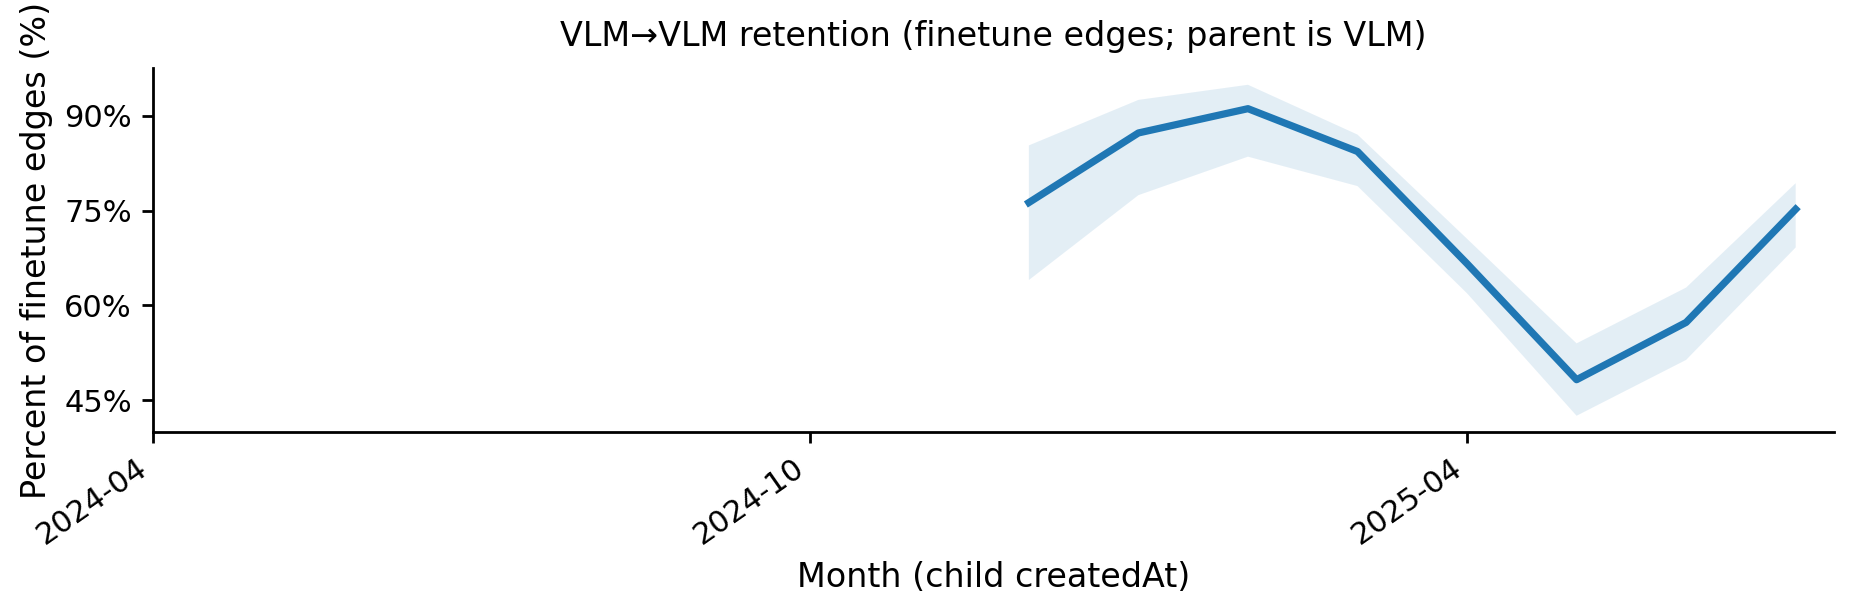

,month,k_vlm_child,n_vlm_parent_edges,rate,ci_lo,ci_hi
4,2024-08,2,2,1.000000,0.342372,1.000000
5,2024-09,15,22,0.681818,0.473182,0.836396
6,2024-10,17,20,0.850000,0.639577,0.947632
7,2024-11,43,47,0.914894,0.800682,0.966406
8,2024-12,45,59,0.762712,0.640249,0.853055
9,2025-01,57,58,0.982759,0.908589,0.996950
10,2025-02,163,165,0.987879,0.956887,0.996670
11,2025-03,155,277,0.559567,0.500684,0.616820
12,2025-04,161,357,0.450980,0.400158,0.502847
13,2025-05,105,240,0.437500,0.376211,0.500759


In [ ]:
months = sorted(den_vlm_parent.keys())

df_vlm_ret = pd.DataFrame({
    "month": months,
    "k_vlm_child": [num_vlm_child[m] for m in months],
    "n_vlm_parent_edges": [den_vlm_parent[m] for m in months],
})
df_vlm_ret["rate"] = df_vlm_ret["k_vlm_child"] / df_vlm_ret["n_vlm_parent_edges"]

cis = [wilson_ci(k, n) for k, n in zip(df_vlm_ret["k_vlm_child"], df_vlm_ret["n_vlm_parent_edges"])]
df_vlm_ret["ci_lo"] = [c[0] for c in cis]
df_vlm_ret["ci_hi"] = [c[1] for c in cis]

# Filter low-n months for readability
MIN_EDGES = 50
dfp = df_vlm_ret.copy()
dfp.loc[dfp["n_vlm_parent_edges"] < MIN_EDGES, ["rate","ci_lo","ci_hi"]] = np.nan

# Light smoothing (optional)
SMOOTH = 3
for c in ["rate","ci_lo","ci_hi"]:
    dfp[c] = dfp[c].rolling(SMOOTH, min_periods=1).mean()

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 700,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(9.4, 3.2))

ax.plot(dfp["month"], 100*dfp["rate"], linewidth=2.6)
ax.fill_between(dfp["month"], 100*dfp["ci_lo"], 100*dfp["ci_hi"], alpha=0.12, linewidth=0)

ax.set_title("VLM→VLM retention (finetune edges; parent is VLM)", pad=8)
ax.set_xlabel("Month (child createdAt)")
ax.set_ylabel("Percent of finetune edges (%)")

ax.grid(False)
ax.yaxis.set_major_locator(mtick.MaxNLocator(4))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))

# x ticks every 6 months
step = 6
xt = dfp["month"].iloc[::step]
ax.set_xticks(xt)
ax.set_xticklabels(xt, rotation=35, ha="right")

fig.tight_layout()
fig.savefig("vlm_retention_over_time.pdf", bbox_inches="tight")
fig.savefig("vlm_retention_over_time.png", bbox_inches="tight")
plt.show()

df_vlm_ret.tail(12)


How to test the “LLM progress transfer to VLM” idea empirically with your dataset

You can do this in a way that stays inside the dataset and doesn’t require benchmark scores:

Test 1: Backbone-lag (“how long until a new text family/version shows up as VLM?”)

For major families (Llama, Qwen, Gemma, Mistral, GLM…), compute:

first month the text-generation version appears

first month a VLM-tagged model in the same family appears (image-text-to-text / image-to-text)

lag = Δmonths

If lags are large and shrinking/expanding over time, that’s direct evidence about transfer speed.

Test 2: Transfer channel accounting (“where do VLM models come from?”)

For VLM children:

fraction with VLM parents (you already have this: ~94.5% for finetune edges)

fraction with text-generation parents

fraction with no recorded parent (roots)

If “roots” dominate at certain times, that suggests transfer happens via new base releases, not via incremental lineage conversion.

Test 3: Founder replacement (“does a new text generation coincide with new VLM founders?”)

Track the top VLM parents by descendant counts over time (your founder concentration plot).
If new founders appear right after major text backbone releases, that’s a signature of punctuated integration events.

A tight framing sentence you can use

“Our results suggest a bottlenecked innovation pipeline: rapid improvements in text-only LLM lineages do not routinely propagate to VLMs through derivative operations, and multimodal progress may therefore depend on relatively rare integration events that create new VLM founders.”

If you want, I can give you 1–2 Colab cells for Test 1 (backbone lag) using simple family regexes on model_id and your pipeline_tag + createdAt—it’s quick and it would make this “know-how bottleneck” framing feel empirically grounded rather than speculative.

In [ ]:
# =========================
# CELL 0 — Setup + helpers
# =========================
from datasets import load_dataset
from tqdm.auto import tqdm
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import ast
import math
import re

DATASET = "modelbiome/ai_ecosystem_withmodelcards"

# If you previously defined USECOLS, we'll use it; otherwise we'll fall back to full rows.
try:
    USECOLS
except NameError:
    USECOLS = ["model_id","pipeline_tag","createdAt",
               "finetune_parent","merge_parent","adapter_parent","quantized_parent"]

PARENT_FIELDS = {
    "finetune": "finetune_parent",
    "merge": "merge_parent",
    "adapter": "adapter_parent",
    "quantized": "quantized_parent",
}

VLM_TASKS = {"image-to-text", "image-text-to-text"}
TEXT_TASK = "text-generation"

# For "cross-modal-any" you can reuse this if needed later
CROSS_MODAL = {
    "text-to-image","image-to-text","image-text-to-text",
    "automatic-speech-recognition","text-to-speech","text-to-video",
    "audio-to-audio","any-to-any"
}

def parse_listish(x):
    if x is None:
        return []
    if isinstance(x, list):
        return [y for y in x if y]
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s == "[]":
            return []
        try:
            v = ast.literal_eval(s)
            if isinstance(v, list):
                return [y for y in v if y]
            return [v] if v else []
        except Exception:
            return []
    return []

def parse_month(createdAt):
    if createdAt is None:
        return None
    if isinstance(createdAt, str) and len(createdAt) >= 7:
        return createdAt[:7]
    return None

def month_to_int(m):  # "YYYY-MM" -> int months
    y, mm = m.split("-")
    return int(y)*12 + int(mm)

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = (z * math.sqrt((p*(1-p) + z*z/(4*n)) / n)) / denom
    return (max(0.0, center-half), min(1.0, center+half))

def stream_ds():
    # reloadable stream (important after any full pass)
    return load_dataset(DATASET, split="train", streaming=True, usecols=USECOLS)

# Optional: if you want to match your Fig1 LLM-family proxy, define is_llm_family(row).
# If undefined, we'll include all models.
if "is_llm_family" not in globals():
    def is_llm_family(row):
        return True

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
})


✅ Test 1 — Backbone-lag (text family appears → first VLM in same family)

This is a single-pass scan with a simple family regex map. You can edit/add families easily.

In [ ]:
# ==========================================
# CELL 1 — Test 1: Family backbone lag plot
# ==========================================
FAMILY_PATTERNS = [
    ("llama",   r"(meta-llama/|llama[-_ ]?)"),
    ("qwen",    r"(qwen/)"),
    ("gemma",   r"(google/)?gemma"),
    ("mistral", r"(mistral(ai)?/)"),
    ("glm",     r"(thudm/|glm)"),
    ("deepseek",r"(deepseek)"),
    ("phi",     r"(microsoft/phi|phi[-_ ]?)"),
    ("falcon",  r"(tiiuae/falcon|falcon[-_ ]?)"),
    ("yi",      r"(/yi-|01-ai/yi|yi[-_ ]?)"),
]

def family_from_model_id(model_id):
    if not model_id:
        return None
    s = model_id.lower()
    for fam, pat in FAMILY_PATTERNS:
        if re.search(pat, s):
            return fam
    return None

RESTRICT_TO_LLM = True  # set False if you want all models (not just LLM-family proxy)

first_text = {}  # family -> month
first_vlm  = {}  # family -> month

ds = stream_ds()
for row in tqdm(ds, desc="Test 1: scanning months", unit="rows"):
    if RESTRICT_TO_LLM and (not is_llm_family(row)):
        continue
    mid = row.get("model_id")
    fam = family_from_model_id(mid)
    if fam is None:
        continue

    m = parse_month(row.get("createdAt"))
    if not m:
        continue

    task = row.get("pipeline_tag")
    if task == TEXT_TASK:
        if fam not in first_text or month_to_int(m) < month_to_int(first_text[fam]):
            first_text[fam] = m
    if task in VLM_TASKS:
        if fam not in first_vlm or month_to_int(m) < month_to_int(first_vlm[fam]):
            first_vlm[fam] = m

rows = []
for fam in sorted(set(first_text) | set(first_vlm)):
    t = first_text.get(fam)
    v = first_vlm.get(fam)
    lag = (month_to_int(v) - month_to_int(t)) if (t and v) else np.nan
    rows.append({"family": fam, "first_text": t, "first_vlm": v, "lag_months": lag})

df_lag = pd.DataFrame(rows).sort_values("lag_months", ascending=False)
df_lag


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/615 [00:00<?, ?B/s]

Test 1: scanning months: 0rows [00:00, ?rows/s]

,family,first_text,first_vlm,lag_months
3,glm,2022-03,2024-05,26
4,llama,2022-03,2023-05,14
1,falcon,2023-03,2024-05,14
7,qwen,2023-08,2024-08,12
5,mistral,2023-09,2024-09,12
8,yi,2022-03,2023-02,11
0,deepseek,2023-10,2024-03,5
6,phi,2022-03,2022-08,5
2,gemma,2024-02,2024-03,1


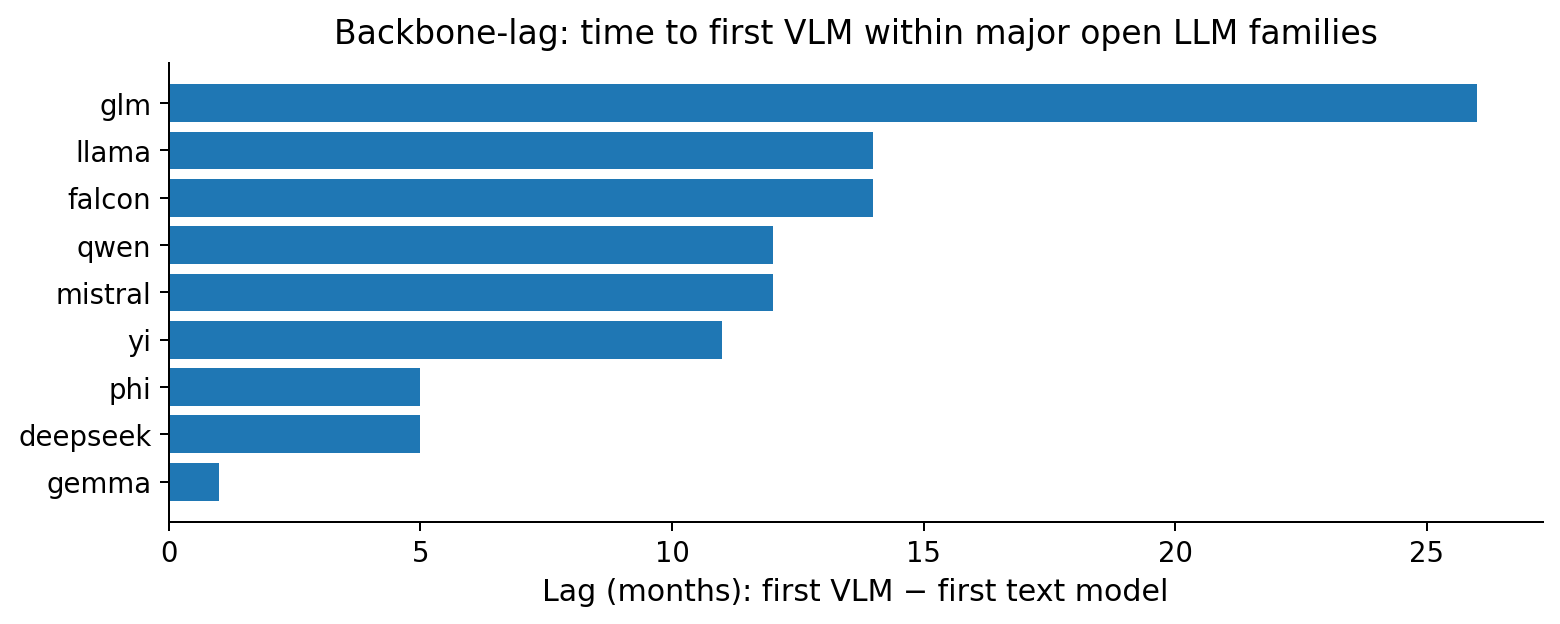

Saved: test1_backbone_lag.pdf/.png


In [ ]:
# Plot: horizontal bar (lag months)
dfp = df_lag.dropna(subset=["lag_months"]).copy()
dfp = dfp.sort_values("lag_months", ascending=True)

fig, ax = plt.subplots(figsize=(8.8, 3.6))
ax.barh(dfp["family"], dfp["lag_months"])
ax.set_xlabel("Lag (months): first VLM − first text model")
ax.set_ylabel("")
ax.set_title("Backbone-lag: time to first VLM within major open LLM families", pad=8)
ax.xaxis.set_major_locator(mtick.MaxNLocator(6))
fig.tight_layout()
fig.savefig("test1_backbone_lag.pdf", bbox_inches="tight")
fig.savefig("test1_backbone_lag.png", bbox_inches="tight")
plt.show()

print("Saved: test1_backbone_lag.pdf/.png")


✅ Test 2 — Transfer channel accounting (where VLM models come from)

This builds a parent_task map for all parent fields, then decomposes VLM models into:

roots (no recorded parent)

has VLM parent

has text parent

other-task parent

unresolved parent (parent exists but task not found)

Outputs both model-level and edge-level shares + plot.

In [ ]:
# ===================================================
# CELL 2 — Test 2: Build parent_task mapping (all)
# ===================================================
RESTRICT_TO_LLM = True  # keep consistent with your paper population

# Pass A: collect all parent IDs we need to resolve
need_parents = set()
ds = stream_ds()
for row in tqdm(ds, desc="Test 2 / Pass A: collecting parents", unit="rows"):
    if RESTRICT_TO_LLM and (not is_llm_family(row)):
        continue
    for _, field in PARENT_FIELDS.items():
        for p in parse_listish(row.get(field)):
            if p:
                need_parents.add(p)

print("Unique parents to resolve:", len(need_parents))

# Pass B: resolve parent pipeline_tag
parent_task = {}
ds = stream_ds()
for row in tqdm(ds, desc="Test 2 / Pass B: resolving parent tasks", unit="rows"):
    mid = row.get("model_id")
    if mid in need_parents:
        parent_task[mid] = row.get("pipeline_tag")
        if len(parent_task) >= len(need_parents):
            break

print("Resolved parent tasks:", len(parent_task), "out of", len(need_parents))


Test 2 / Pass A: collecting parents: 0rows [00:00, ?rows/s]

Unique parents to resolve: 53841


Test 2 / Pass B: resolving parent tasks: 0rows [00:00, ?rows/s]

Resolved parent tasks: 51406 out of 53841


In [ ]:
# ==========================================================
# CELL 3 — Test 2: Decompose VLM models by transfer channel
# ==========================================================
def classify_parent_task(ptask):
    if ptask in VLM_TASKS:
        return "VLM parent"
    if ptask == TEXT_TASK:
        return "Text parent"
    if ptask is None:
        return "Unresolved parent"
    return "Other-task parent"

vlm_model_source = Counter()     # model-level: each VLM model counted once
vlm_edge_source  = Counter()     # edge-level: each parent edge counted
vlm_total_models = 0
unresolved_edges = 0

ds = stream_ds()
for row in tqdm(ds, desc="Test 2 / Pass C: channel accounting", unit="rows"):
    if RESTRICT_TO_LLM and (not is_llm_family(row)):
        continue

    child_task = row.get("pipeline_tag")
    if child_task not in VLM_TASKS:
        continue

    vlm_total_models += 1

    # collect all parents for this child
    parents = []
    for _, field in PARENT_FIELDS.items():
        parents.extend(parse_listish(row.get(field)))

    if not parents:
        vlm_model_source["Root (no recorded parent)"] += 1
        continue

    # edge-level counts + model-level best category
    cats_present = set()
    for p in parents:
        ptask = parent_task.get(p)
        if ptask is None:
            unresolved_edges += 1
            cat = "Unresolved parent"
        else:
            cat = classify_parent_task(ptask)

        vlm_edge_source[cat] += 1
        cats_present.add(cat)

    # model-level: prioritize strongest lineage interpretation
    if "VLM parent" in cats_present:
        vlm_model_source["Has VLM parent"] += 1
    elif "Text parent" in cats_present:
        vlm_model_source["Has text parent"] += 1
    elif "Other-task parent" in cats_present:
        vlm_model_source["Has other-task parent"] += 1
    else:
        vlm_model_source["Has unresolved parent only"] += 1

print("Total VLM models (in sample):", vlm_total_models)
print("Unresolved parent edges:", unresolved_edges)

df_model = (pd.DataFrame(vlm_model_source.items(), columns=["source","n_models"])
              .assign(share=lambda d: d["n_models"]/d["n_models"].sum())
              .sort_values("share", ascending=False))

df_edge = (pd.DataFrame(vlm_edge_source.items(), columns=["edge_source","n_edges"])
             .assign(share=lambda d: d["n_edges"]/d["n_edges"].sum())
             .sort_values("share", ascending=False))

df_model, df_edge


Test 2 / Pass C: channel accounting: 0rows [00:00, ?rows/s]

Total VLM models (in sample): 12371
Unresolved parent edges: 126


(                       source  n_models     share
 2   Root (no recorded parent)      7752  0.626627
 1              Has VLM parent      4132  0.334007
 0             Has text parent       299  0.024169
 4       Has other-task parent        98  0.007922
 3  Has unresolved parent only        90  0.007275,
          edge_source  n_edges     share
 1         VLM parent     4167  0.868668
 0        Text parent      329  0.068585
 3  Other-task parent      175  0.036481
 2  Unresolved parent      126  0.026266)

/tmp/ipython-input-58522862.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dfp["source"], rotation=25, ha="right")


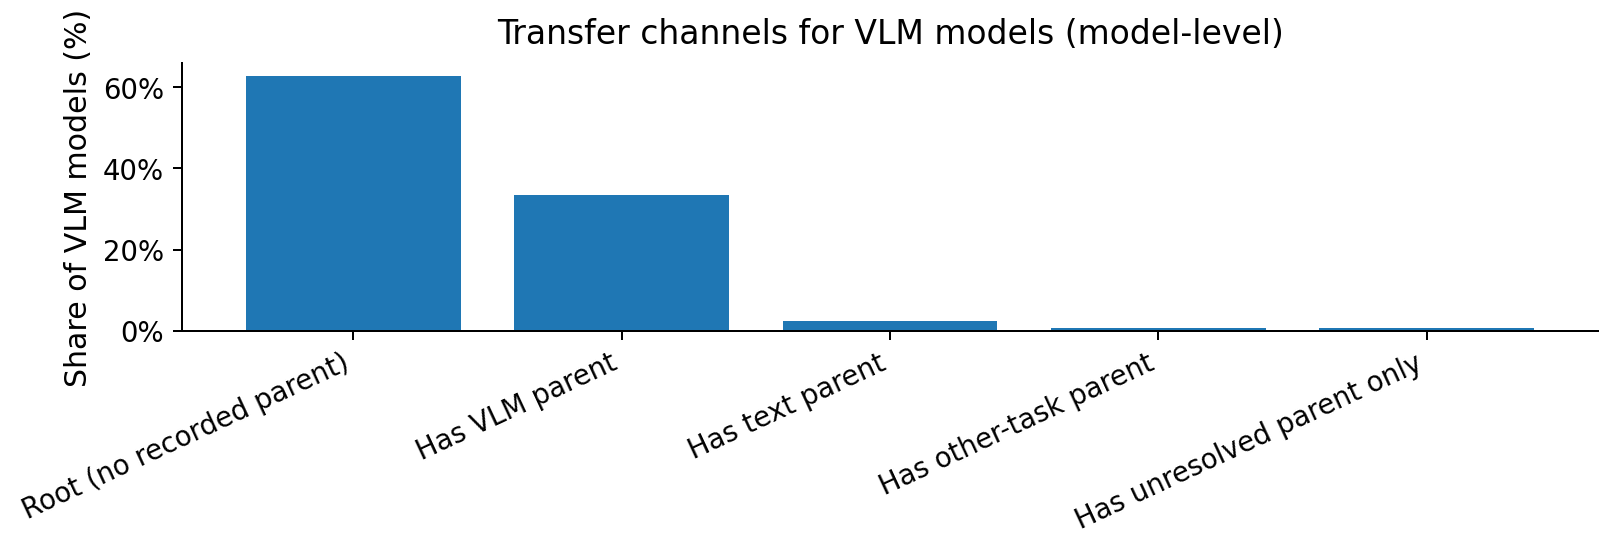

Saved: test2_vlm_transfer_channels_model.pdf/.png


In [ ]:
# Plot model-level shares (clean bar chart)
dfp = df_model.copy()
fig, ax = plt.subplots(figsize=(9.2, 3.2))
ax.bar(dfp["source"], 100*dfp["share"])
ax.set_ylabel("Share of VLM models (%)")
ax.set_title("Transfer channels for VLM models (model-level)", pad=8)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.set_xticklabels(dfp["source"], rotation=25, ha="right")
ax.yaxis.set_major_locator(mtick.MaxNLocator(4))
fig.tight_layout()
fig.savefig("test2_vlm_transfer_channels_model.pdf", bbox_inches="tight")
fig.savefig("test2_vlm_transfer_channels_model.png", bbox_inches="tight")
plt.show()

print("Saved: test2_vlm_transfer_channels_model.pdf/.png")


✅ Test 3 — Founder replacement / dominance over time (within VLM→VLM edges)

We compute for finetune edges where parent is VLM and child is VLM:

top-1 and top-3 founder share over time

“effective number of founders”
𝑁
e
f
f
=
1
/
H
H
I
N
eff
	​

=1/HHI over time

top founders overall

In [ ]:
# ======================================================
# CELL 4 — Test 3: Founder dominance over time (finetune)
# ======================================================
RESTRICT_TO_LLM = True

vlm_vlm_edges_by_month = Counter()
top_counter_by_month = defaultdict(Counter)  # month -> Counter(parent_id -> count)

ds = stream_ds()
unresolved = 0

for row in tqdm(ds, desc="Test 3: counting VLM→VLM founder edges", unit="rows"):
    if RESTRICT_TO_LLM and (not is_llm_family(row)):
        continue

    child_task = row.get("pipeline_tag")
    if child_task not in VLM_TASKS:
        continue

    m = parse_month(row.get("createdAt"))
    if not m:
        continue

    parents = parse_listish(row.get(PARENT_FIELDS["finetune"]))
    if not parents:
        continue

    for p in parents:
        ptask = parent_task.get(p)
        if ptask is None:
            unresolved += 1
            continue
        if ptask in VLM_TASKS:
            vlm_vlm_edges_by_month[m] += 1
            top_counter_by_month[m][p] += 1

print("Unresolved parent lookups (edges):", unresolved)
print("Total VLM→VLM finetune edges:", sum(vlm_vlm_edges_by_month.values()))


Test 3: counting VLM→VLM founder edges: 0rows [00:00, ?rows/s]

Unresolved parent lookups (edges): 64
Total VLM→VLM finetune edges: 2790


In [ ]:
# Build monthly concentration dataframe
rows = []
for m in sorted(vlm_vlm_edges_by_month.keys()):
    ctr = top_counter_by_month[m]
    tot = sum(ctr.values())
    if tot == 0:
        continue
    top1 = ctr.most_common(1)[0][1]
    top3 = sum(c for _, c in ctr.most_common(3))

    shares = np.array([c/tot for c in ctr.values()])
    hhi = float(np.sum(shares**2))
    n_eff = float(1/hhi) if hhi > 0 else np.nan

    rows.append({
        "month": m,
        "vlm_vlm_edges": tot,
        "top1_share": top1/tot,
        "top3_share": top3/tot,
        "HHI": hhi,
        "N_eff": n_eff,
        "n_unique_parents": len(ctr),
    })

df_found = pd.DataFrame(rows)

# Hide ultra-low-n months for plot readability
MIN_EDGES = 25
dfp = df_found.copy()
dfp.loc[dfp["vlm_vlm_edges"] < MIN_EDGES, ["top1_share","top3_share","N_eff"]] = np.nan

df_found.tail(12)


,month,vlm_vlm_edges,top1_share,top3_share,HHI,N_eff,n_unique_parents
16,2024-08,19,0.105263,0.315789,0.069252,14.440000,16
17,2024-09,45,0.088889,0.244444,0.048889,20.454545,28
18,2024-10,87,0.149425,0.413793,0.075704,13.209424,33
19,2024-11,80,0.100000,0.250000,0.042500,23.529412,41
20,2024-12,144,0.312500,0.423611,0.116127,8.611296,49
21,2025-01,157,0.121019,0.286624,0.048075,20.800844,47
22,2025-02,232,0.431034,0.603448,0.210389,4.753091,47
23,2025-03,279,0.086022,0.240143,0.041867,23.884934,64
24,2025-04,315,0.101587,0.273016,0.039476,25.331887,91
25,2025-05,293,0.109215,0.269625,0.037519,26.652903,79


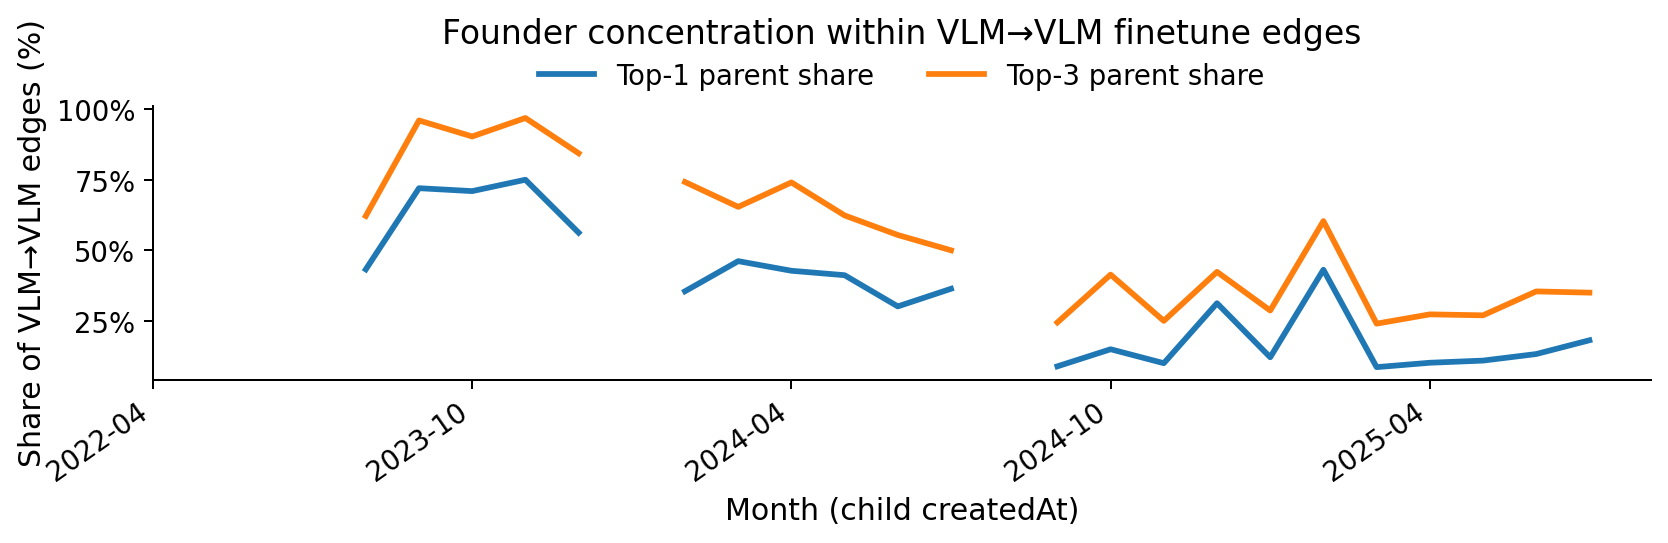

Saved: test3_founder_concentration_over_time.pdf/.png


In [ ]:
# Plot: founder concentration over time (top1/top3)
fig, ax = plt.subplots(figsize=(9.4, 3.2))
ax.plot(dfp["month"], 100*dfp["top1_share"], linewidth=2.3, label="Top-1 parent share")
ax.plot(dfp["month"], 100*dfp["top3_share"], linewidth=2.3, label="Top-3 parent share")
ax.set_title("Founder concentration within VLM→VLM finetune edges", pad=25)
ax.set_xlabel("Month (child createdAt)")
ax.set_ylabel("Share of VLM→VLM edges (%)")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.yaxis.set_major_locator(mtick.MaxNLocator(4))
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.25))

step = 6
xt = dfp["month"].iloc[::step]
ax.set_xticks(xt)
ax.set_xticklabels(xt, rotation=35, ha="right")

fig.tight_layout()
fig.savefig("test3_founder_concentration_over_time.pdf", bbox_inches="tight")
fig.savefig("test3_founder_concentration_over_time.png", bbox_inches="tight")
plt.show()

print("Saved: test3_founder_concentration_over_time.pdf/.png")


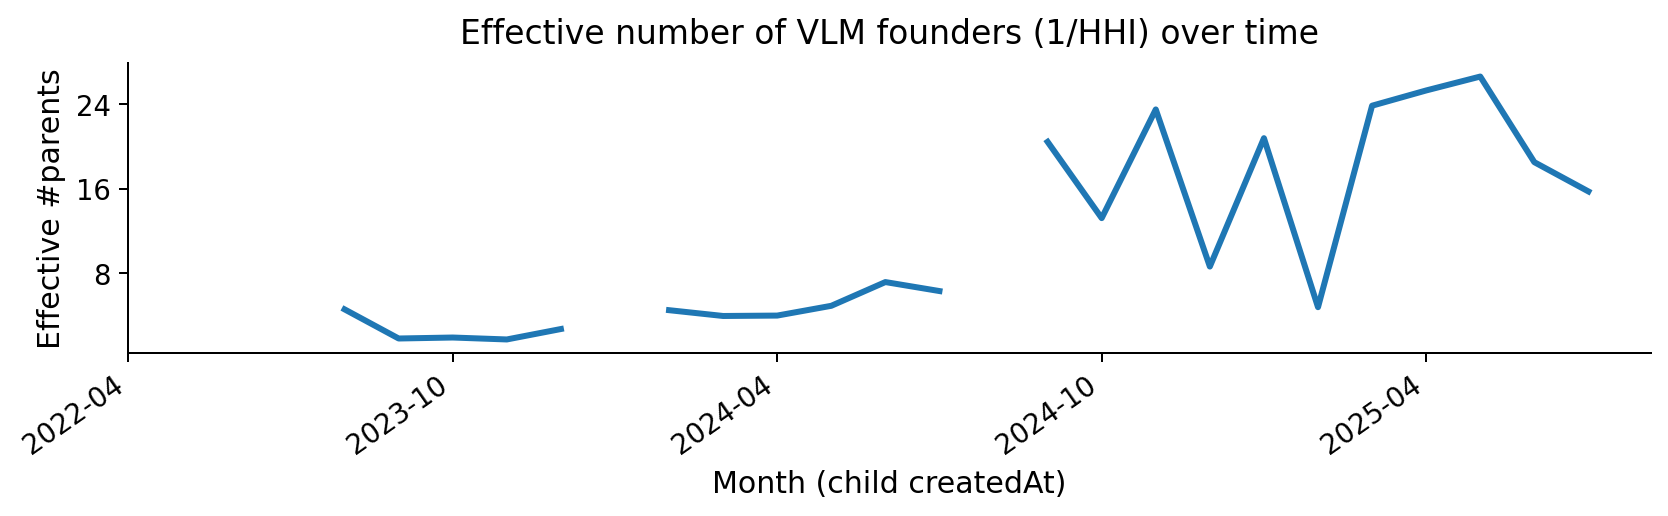

Saved: test3_effective_founders_over_time.pdf/.png


In [ ]:
# Plot: effective number of founders over time
fig, ax = plt.subplots(figsize=(9.4, 3.0))
ax.plot(dfp["month"], dfp["N_eff"], linewidth=2.4)
ax.set_title("Effective number of VLM founders (1/HHI) over time", pad=8)
ax.set_xlabel("Month (child createdAt)")
ax.set_ylabel("Effective #parents")
ax.yaxis.set_major_locator(mtick.MaxNLocator(4))

xt = dfp["month"].iloc[::6]
ax.set_xticks(xt)
ax.set_xticklabels(xt, rotation=35, ha="right")

fig.tight_layout()
fig.savefig("test3_effective_founders_over_time.pdf", bbox_inches="tight")
fig.savefig("test3_effective_founders_over_time.png", bbox_inches="tight")
plt.show()

print("Saved: test3_effective_founders_over_time.pdf/.png")


,parent_model_id,vlm_vlm_edges,share_%
0,naver-clova-ix/donut-base,417,28.213802
1,llava-hf/llava-v1.6-mistral-7b-hf,167,11.299053
2,Qwen/Qwen2.5-VL-3B-Instruct,138,9.336942
3,Qwen/Qwen2.5-VL-7B-Instruct,127,8.592693
4,microsoft/git-base,107,7.239513
5,Qwen/Qwen2-VL-2B-Instruct,95,6.427605
6,Qwen/Qwen2-VL-7B-Instruct,70,4.736130
7,unsloth/gemma-3-4b-it-unsloth-bnb-4bit,52,3.518268
8,google/gemma-3-27b-it,52,3.518268
9,google/gemma-3-4b-it,51,3.450609


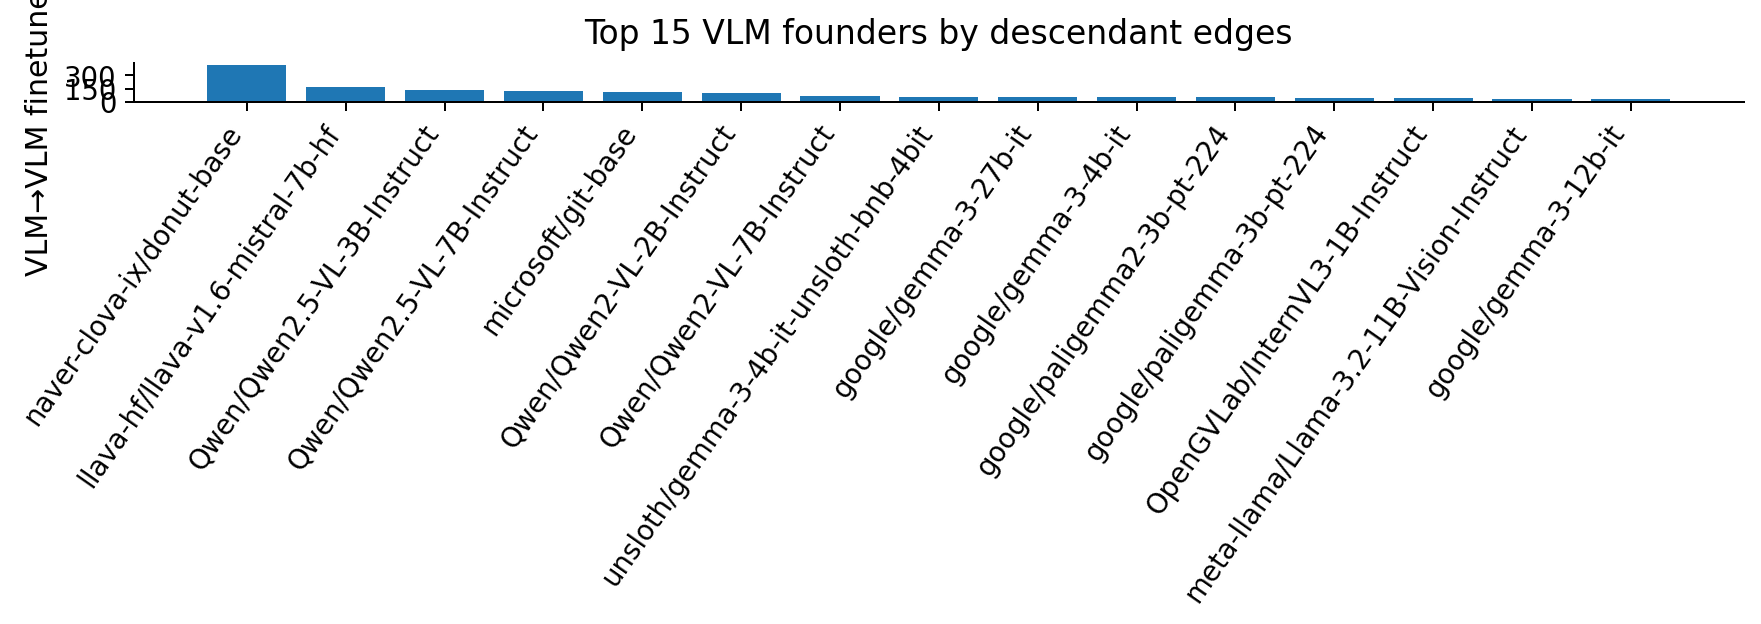

Saved: test3_top_vlm_founders.pdf/.png


In [ ]:
# Top founders overall (bar plot)
overall = Counter()
for m, ctr in top_counter_by_month.items():
    overall.update(ctr)

topN = 15
top_df = pd.DataFrame(overall.most_common(topN), columns=["parent_model_id","vlm_vlm_edges"])
top_df["share_%"] = 100*top_df["vlm_vlm_edges"]/top_df["vlm_vlm_edges"].sum()

display(top_df)

fig, ax = plt.subplots(figsize=(10.0, 3.6))
ax.bar(range(len(top_df)), top_df["vlm_vlm_edges"])
ax.set_xticks(range(len(top_df)))
ax.set_xticklabels(top_df["parent_model_id"], rotation=55, ha="right")
ax.set_ylabel("VLM→VLM finetune edges")
ax.set_title(f"Top {topN} VLM founders by descendant edges", pad=8)
ax.yaxis.set_major_locator(mtick.MaxNLocator(4))
fig.tight_layout()
fig.savefig("test3_top_vlm_founders.pdf", bbox_inches="tight")
fig.savefig("test3_top_vlm_founders.png", bbox_inches="tight")
plt.show()

print("Saved: test3_top_vlm_founders.pdf/.png")
